# Stage 0) -- Import libraries

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score
from sklearn.ensemble import IsolationForest

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

In [2]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device selection (Mac MPS / CUDA / CPU)
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Device:", device)

Device: mps


# Stage 1) -- Data preparation

### Load Electricity Dataset

In [3]:
df = pd.read_csv(
    "LD2011_2014.txt",
    sep=";",
    index_col=0,
    parse_dates=True,
    decimal=","
)

print("Original shape:", df.shape)

Original shape: (140256, 370)


### Clean data and hourly resampling

In [4]:
# Convert to numeric, coercing errors to NaN, then fill NaNs with 0
df = df.apply(pd.to_numeric, errors="coerce").fillna(0)

# Hourly resample
df_hourly = df.resample("H").sum()
print("Hourly shape:", df_hourly.shape)

# Remove meters that are completely zero
df_hourly = df_hourly.loc[:, df_hourly.sum() > 0]
print("After removing all-zero meters:", df_hourly.shape)

Hourly shape: (35065, 370)
After removing all-zero meters: (35065, 370)


/var/folders/dw/616cv9cd1fn1gjnkvzk36vvw0000gn/T/ipykernel_38425/197563779.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df.resample("H").sum()


### Time-based Train/Validation Split (Leakage Prevention)

In [5]:
# 1) Split by time FIRST
split_idx = int(len(df_hourly) * 0.8)
df_train = df_hourly.iloc[:split_idx].copy()
df_val   = df_hourly.iloc[split_idx:].copy()

print("Train range:", df_train.index.min(), "->", df_train.index.max(), df_train.shape)
print("Val range  :", df_val.index.min(),   "->", df_val.index.max(),   df_val.shape)

# 2) Choose top-K meters USING TRAIN ONLY
K = 30
meters = df_train.sum().sort_values(ascending=False).head(K).index.tolist()
print(f"Selected top-K meters: K={K}")

df_train = df_train[meters]
df_val   = df_val[meters]

print("After selecting K meters:")
print("Train shape:", df_train.shape)
print("Val shape  :", df_val.shape)

Train range: 2011-01-01 00:00:00 -> 2014-03-14 19:00:00 (28052, 370)
Val range  : 2014-03-14 20:00:00 -> 2015-01-01 00:00:00 (7013, 370)
Selected top-K meters: K=30
After selecting K meters:
Train shape: (28052, 30)
Val shape  : (7013, 30)


### Standardization per meter feature (fit on train only)

In [6]:
scaler = StandardScaler()
train_scaled = pd.DataFrame(
    scaler.fit_transform(df_train),
    index=df_train.index,
    columns=df_train.columns
)

val_scaled = pd.DataFrame(
    scaler.transform(df_val),
    index=df_val.index,
    columns=df_val.columns
)

print("Scaled train shape:", train_scaled.shape)
print("Scaled val shape:", val_scaled.shape)

Scaled train shape: (28052, 30)
Scaled val shape: (7013, 30)


### Create multivariate windows: X shape (N, 168, K)

In [7]:
seq_len = 168  

train_mat = train_scaled.values.astype(np.float32)
val_mat = val_scaled.values.astype(np.float32)

X_train = np.array(
    [train_mat[i:i+seq_len, :] for i in range(len(train_mat) - seq_len)],
    dtype=np.float32
)

X_val = np.array(
    [val_mat[i:i+seq_len, :] for i in range(len(val_mat) - seq_len)],
    dtype=np.float32
)

train_window_end_times = df_train.index[seq_len:]
val_window_end_times   = df_val.index[seq_len:]

print("X_train shape:", X_train.shape)
print("X_val shape  :", X_val.shape)
print("Val window time range:", val_window_end_times[0], "to", val_window_end_times[-1])

X_train shape: (27884, 168, 30)
X_val shape  : (6845, 168, 30)
Val window time range: 2014-03-21 20:00:00 to 2015-01-01 00:00:00


### Data Preparation Summary

In [8]:
summary = pd.DataFrame({
    "Item": [
        "Train rows (after split)",
        "Validation rows (after split)",
        "Selected meters (K)",
        "Sequence length (hours)",
        "Train windows",
        "Validation windows"
    ],
    "Value": [
        len(df_train),
        len(df_val),
        K,
        seq_len,
        len(X_train),
        len(X_val)
    ]
})

summary

,Item,Value
0,Train rows (after split),28052
1,Validation rows (after split),7013
2,Selected meters (K),30
3,Sequence length (hours),168
4,Train windows,27884
5,Validation windows,6845


# Stage 2) - Training Setup

### Dataloaders

In [9]:
batch_size = 64 

train_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_train), torch.from_numpy(X_train)),
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)

val_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_val), torch.from_numpy(X_val)),
    batch_size=batch_size,
    shuffle=False
)

xb, yb = next(iter(train_loader))
print("Batch X:", xb.shape)
print("Batch y:", yb.shape)

Batch X: torch.Size([64, 168, 30])
Batch y: torch.Size([64, 168, 30])


# Separate section for utilities here below code only 

### Synthetic Anomaly Injection Utilities

In [10]:
# create fake anomalies and ground-truth labels
def inject_synthetic_anomalies(X_in, frac=0.05, seed=42):
    """
    Inject anomalies into random windows and random channels.
    Returns (X_corrupt, y_true) where y_true=1 for anomalous windows.
    """
    rng = np.random.default_rng(seed)
    Xc = X_in.copy()
    y = np.zeros(len(Xc), dtype=int)

    n_anom = int(frac * len(Xc))
    idx = rng.choice(len(Xc), size=n_anom, replace=False)

    T = Xc.shape[1]
    C = Xc.shape[2]

    for i in idx:
        kind = rng.choice(["spike", "drop", "shift"])
        t0 = int(rng.integers(0, T - 6))
        c0 = int(rng.integers(0, C)) 

        if kind == "spike":
            Xc[i, t0:t0+6, c0] *= rng.uniform(3, 8)
        elif kind == "drop":
            Xc[i, t0:t0+6, c0] *= rng.uniform(0.0, 0.2)
        else:  # shift
            Xc[i, t0:, c0] += rng.uniform(1.5, 3.0)

        y[i] = 1

    return Xc, y


# calculate PR-AUC 
def pr_auc_from_scores(y_true, scores):
    return average_precision_score(y_true, scores)


# compute anomaly score using reconstruction error
def window_mse_torch(model, X_np, device, batch_size=256):
    """
    Returns per-window reconstruction MSE averaged over (time, channels).
    X_np: (N, T, C)
    """
    model.eval()
    errs = []
    with torch.no_grad():
        for i in range(0, len(X_np), batch_size):
            xb = torch.from_numpy(X_np[i:i+batch_size]).float().to(device)
            pred = model(xb)
            e = torch.mean((pred - xb) ** 2, dim=(1,2))
            errs.append(e.detach().cpu().numpy())
    return np.concatenate(errs)

In [11]:
def window_score_max_channel(model, X_np, device, batch_size=256):
    model.eval()
    scores = []
    with torch.no_grad():
        for i in range(0, len(X_np), batch_size):
            xb = torch.from_numpy(X_np[i:i+batch_size]).float().to(device)
            pred = model(xb)

            # MSE per channel (mean over time only) -> (B, C)
            per_channel_mse = torch.mean((pred - xb) ** 2, dim=1)

            # score = maximum channel error -> (B,)
            score = torch.max(per_channel_mse, dim=1).values
            scores.append(score.detach().cpu().numpy())

    return np.concatenate(scores)

# Stage 3) - Model training

### Transformer Autoencoder Architecture

In [12]:
# Positional encoding
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-torch.log(torch.tensor(10000.0)) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0)) 

    def forward(self, x):
        T = x.size(1)
        return x + self.pe[:, :T, :]


class TransformerAE(nn.Module):
    def __init__(self, seq_len=168, in_dim=30, d_model=64, nhead=4, num_layers=2, bottleneck=16, dropout=0.1):
        super().__init__()
        self.in_proj = nn.Linear(in_dim, d_model)
        self.pos = PositionalEncoding(d_model, max_len=seq_len)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dropout=dropout, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        self.to_latent = nn.Linear(d_model, bottleneck)
        self.from_latent = nn.Linear(bottleneck, d_model)

        dec_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dropout=dropout, batch_first=True
        )
        self.decoder = nn.TransformerEncoder(dec_layer, num_layers=num_layers)

        self.out_proj = nn.Linear(d_model, in_dim)

    def forward(self, x):
        h = self.in_proj(x)
        h = self.pos(h)
        h = self.encoder(h)
        z = self.to_latent(h)
        h2 = self.from_latent(z)
        h2 = self.decoder(h2)
        y = self.out_proj(h2)
        return y

    def encode(self, x):
        h = self.in_proj(x)
        h = self.pos(h)
        h = self.encoder(h)
        z = self.to_latent(h)
        return z

### Train Transformer Autoencoder 

In [13]:
def train_ae(model, train_loader, val_loader, device, epochs=20, lr=1e-3):
    model.to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    def run(loader, train=True):
        model.train(train)
        total, n = 0.0, 0
        for xb, yb in loader:
            xb, yb = xb.to(device).float(), yb.to(device).float()
            if train:
                opt.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            if train:
                loss.backward()
                opt.step()
            total += loss.item() * xb.size(0)
            n += xb.size(0)
        return total / n

    for ep in range(1, epochs+1):
        tr = run(train_loader, True)
        va = run(val_loader, False)
        print(f"Epoch {ep:02d} | train MSE: {tr:.6f} | val MSE: {va:.6f}")

    return model

In [14]:
transformer_ae = TransformerAE(seq_len=seq_len, in_dim=K, d_model=64, nhead=4, num_layers=2, bottleneck=16, dropout=0.1)
transformer_ae = train_ae(transformer_ae, train_loader, val_loader, device, epochs=20, lr=1e-3)

Epoch 01 | train MSE: 0.095076 | val MSE: 0.047109
Epoch 02 | train MSE: 0.022247 | val MSE: 0.034647
Epoch 03 | train MSE: 0.014386 | val MSE: 0.031088
Epoch 04 | train MSE: 0.011232 | val MSE: 0.030723
Epoch 05 | train MSE: 0.009371 | val MSE: 0.029451
Epoch 06 | train MSE: 0.008092 | val MSE: 0.028515
Epoch 07 | train MSE: 0.007187 | val MSE: 0.027133
Epoch 08 | train MSE: 0.006648 | val MSE: 0.027245
Epoch 09 | train MSE: 0.006041 | val MSE: 0.028679
Epoch 10 | train MSE: 0.005674 | val MSE: 0.026090
Epoch 11 | train MSE: 0.005410 | val MSE: 0.026651
Epoch 12 | train MSE: 0.005079 | val MSE: 0.025755
Epoch 13 | train MSE: 0.004852 | val MSE: 0.026877
Epoch 14 | train MSE: 0.004597 | val MSE: 0.026964
Epoch 15 | train MSE: 0.004502 | val MSE: 0.026951
Epoch 16 | train MSE: 0.004218 | val MSE: 0.026942
Epoch 17 | train MSE: 0.004095 | val MSE: 0.027516
Epoch 18 | train MSE: 0.003976 | val MSE: 0.027506
Epoch 19 | train MSE: 0.003848 | val MSE: 0.026987
Epoch 20 | train MSE: 0.003774 

### Evaluate Transformer Autoencoder (PR-AUC)

In [15]:
# pick an active meter (mostly non-zero readings)
X_val_corrupt_tf, y_true_tf = inject_synthetic_anomalies(X_val, frac=0.05, seed=42)
scores_tf = window_score_max_channel(transformer_ae, X_val_corrupt_tf, device=device, batch_size=256)
pr_auc_tf = pr_auc_from_scores(y_true_tf, scores_tf)
print("Transformer AE PR-AUC:", pr_auc_tf)

Transformer AE PR-AUC: 0.4051520611704121


In [16]:
print("encode exists:", hasattr(TransformerAE, "encode"))

encode exists: True


In [17]:
test = torch.tensor(X_train[:2], dtype=torch.float32).to(device)
print(transformer_ae.encode(test).shape) 

torch.Size([2, 168, 16])


<Axes: >

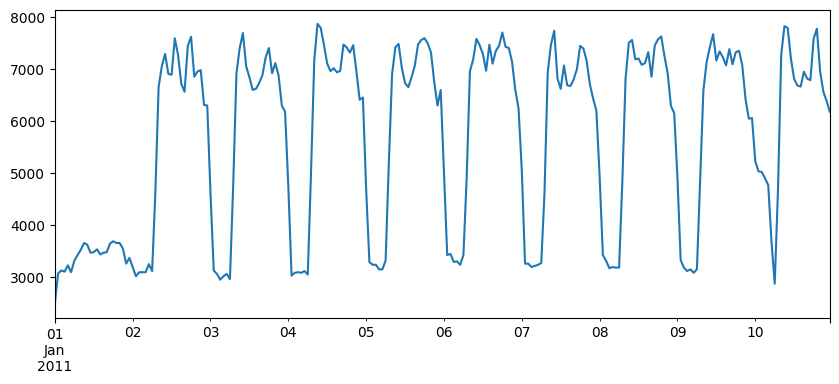

In [18]:
df_hourly["MT_166"].loc["2011-01-01":"2011-01-10"].plot(figsize=(10,4))

# Stage 4) - Anomaly detection and Analysis

### Find the number of flagged anomalies

In [43]:
mu = val_err_tf_clean.mean()
sigma = val_err_tf_clean.std()

thr_p99 = np.percentile(val_err_tf_clean, 99)
thr_2s = mu + 2 * sigma
thr_3s = mu + 3 * sigma

mask_p99 = val_err_tf_clean >= thr_p99
mask_2s = val_err_tf_clean >= thr_2s
mask_3s = val_err_tf_clean >= thr_3s

print("p99 anomalies:", mask_p99.sum(), "out of", len(mask_p99))
print("2σ anomalies:", mask_2s.sum(), "out of", len(mask_2s))
print("3σ anomalies:", mask_3s.sum(), "out of", len(mask_3s))

p99 anomalies: 69 out of 6845
2σ anomalies: 364 out of 6845
3σ anomalies: 39 out of 6845


In [44]:
print("p99 anomalies:", (val_err_tf_clean >= thr_p99).sum(), "out of", len(val_err_tf_clean))
print("2σ anomalies:", mask_2s.sum(), "out of", len(mask_2s))
print("3σ anomalies:", mask_3s.sum(), "out of", len(mask_3s))

p99 anomalies: 69 out of 6845
2σ anomalies: 364 out of 6845
3σ anomalies: 39 out of 6845


### Visualize anomaly scores with thresholds

Validation time range: 2014-03-21 20:00:00 to 2015-01-01 00:00:00
Anomalies flagged (p99): 69 out of 6845


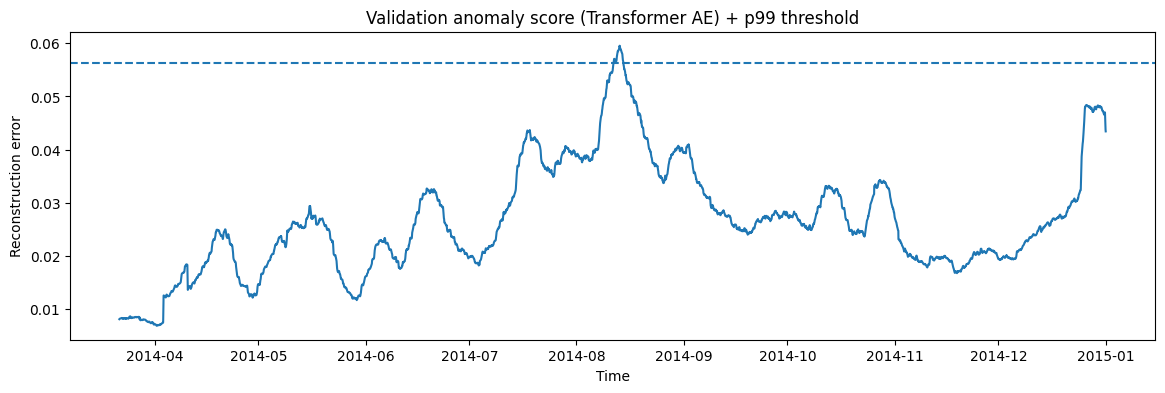

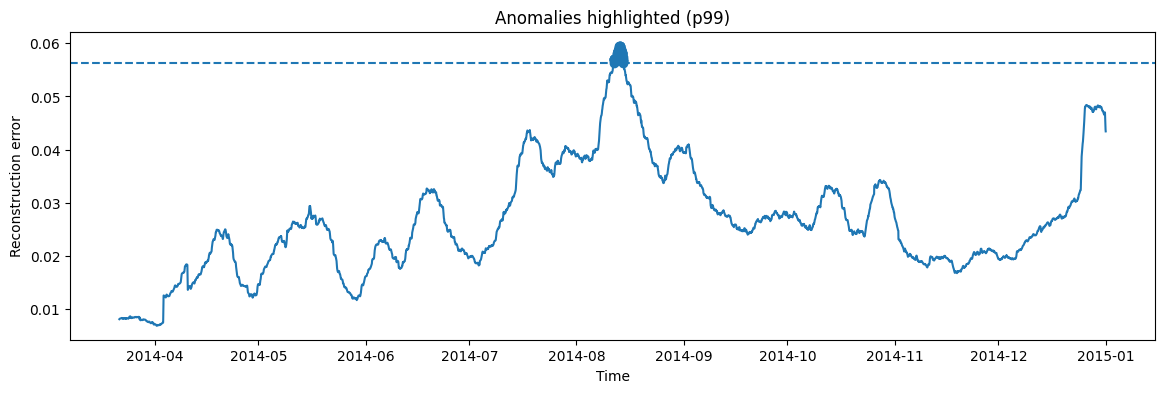

In [21]:
val_err_tf_clean = window_mse_torch(transformer_ae, X_val, device=device, batch_size=256)

thr_p99 = np.percentile(val_err_tf_clean, 99)
val_anom = val_err_tf_clean >= thr_p99

all_window_end_times = df_hourly.index[seq_len:]        
val_window_end_times = all_window_end_times[-len(X_val):]

print("Validation time range:", val_window_end_times[0], "to", val_window_end_times[-1])
print("Anomalies flagged (p99):", val_anom.sum(), "out of", len(val_anom))

plt.figure(figsize=(14,4))
plt.plot(val_window_end_times, val_err_tf_clean)
plt.axhline(thr_p99, linestyle="--")
plt.title("Validation anomaly score (Transformer AE) + p99 threshold")
plt.xlabel("Time")
plt.ylabel("Reconstruction error")
plt.show()

plt.figure(figsize=(14,4))
plt.plot(val_window_end_times, val_err_tf_clean)
plt.scatter(val_window_end_times[val_anom], val_err_tf_clean[val_anom])
plt.axhline(thr_p99, linestyle="--")
plt.title("Anomalies highlighted (p99)")
plt.xlabel("Time")
plt.ylabel("Reconstruction error")
plt.show()

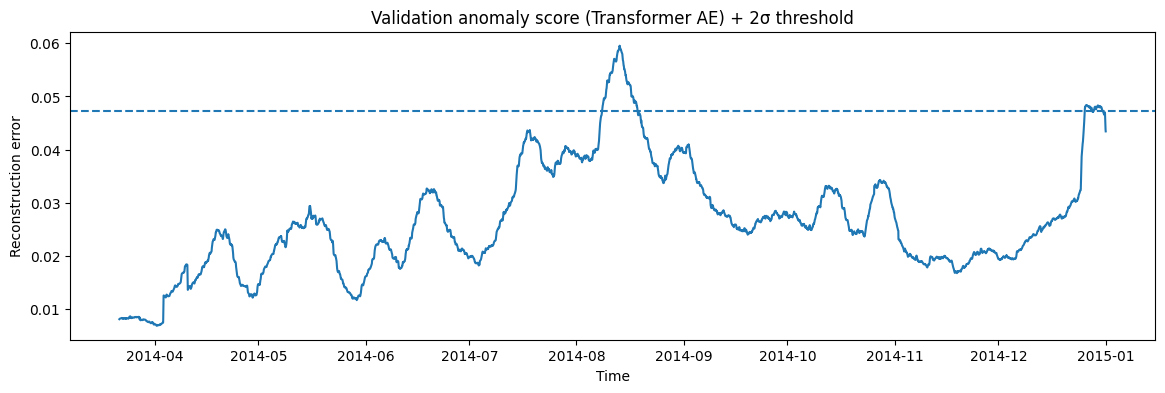

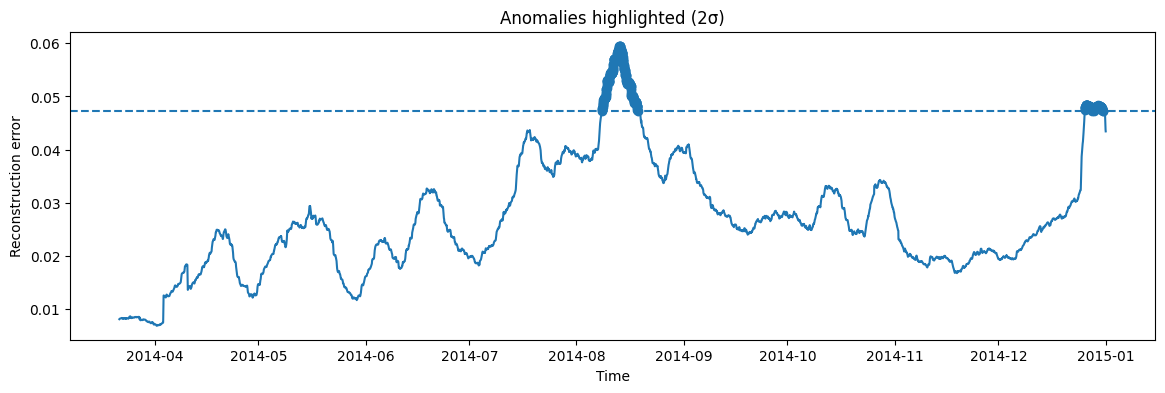

In [45]:
mask_2s = val_err_tf_clean >= thr_2s

plt.figure(figsize=(14,4))
plt.plot(val_window_end_times, val_err_tf_clean)
plt.axhline(thr_2s, linestyle="--")
plt.title("Validation anomaly score (Transformer AE) + 2σ threshold")
plt.xlabel("Time")
plt.ylabel("Reconstruction error")
plt.show()

plt.figure(figsize=(14,4))
plt.plot(val_window_end_times, val_err_tf_clean)
plt.scatter(val_window_end_times[mask_2s], val_err_tf_clean[mask_2s])
plt.axhline(thr_2s, linestyle="--")
plt.title("Anomalies highlighted (2σ)")
plt.xlabel("Time")
plt.ylabel("Reconstruction error")
plt.show()

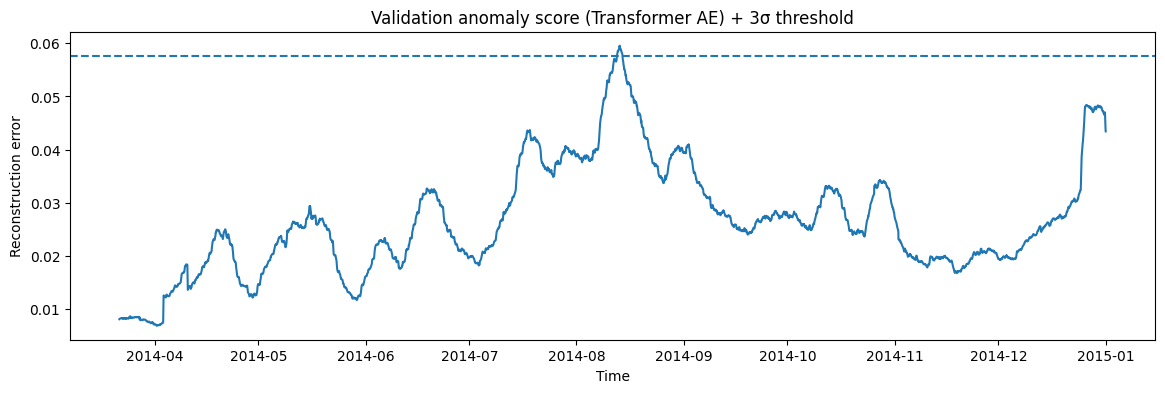

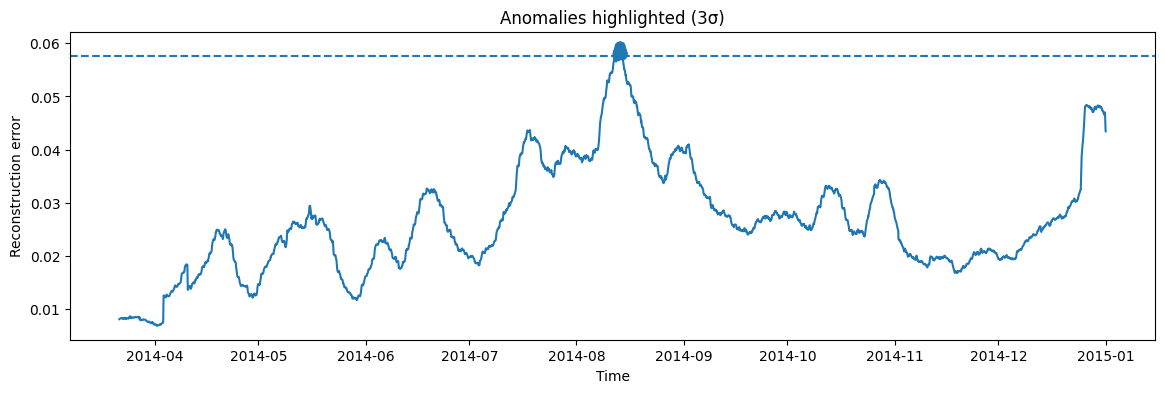

In [51]:
mask_3s = val_err_tf_clean >= thr_3s

plt.figure(figsize=(14,4))
plt.plot(val_window_end_times, val_err_tf_clean)
plt.axhline(thr_3s, linestyle="--")
plt.title("Validation anomaly score (Transformer AE) + 3σ threshold")
plt.xlabel("Time")
plt.ylabel("Reconstruction error")
plt.show()

plt.figure(figsize=(14,4))
plt.plot(val_window_end_times, val_err_tf_clean)
plt.scatter(val_window_end_times[mask_3s], val_err_tf_clean[mask_3s])
plt.axhline(thr_3s, linestyle="--")
plt.title("Anomalies highlighted (3σ)")
plt.xlabel("Time")
plt.ylabel("Reconstruction error")
plt.show() 

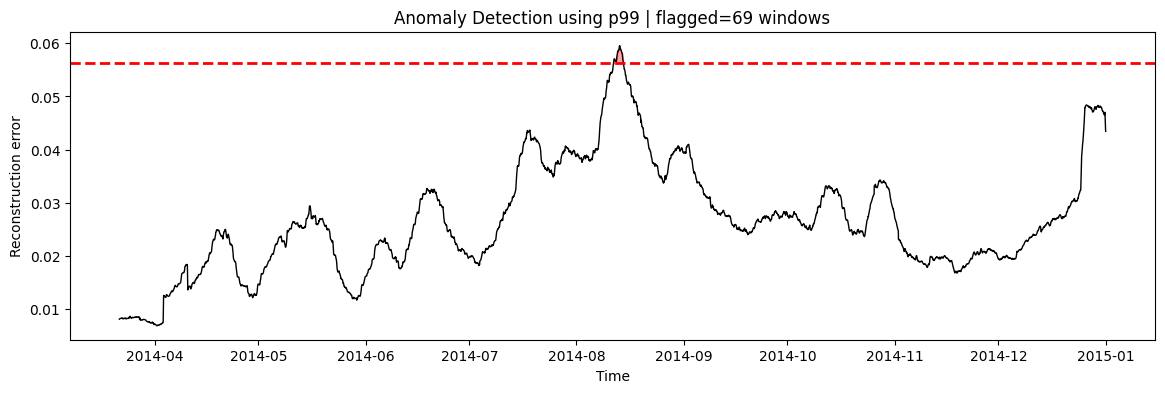

In [24]:
plt.figure(figsize=(14,4))
plt.plot(val_window_end_times, val_err_tf_clean, color="black", linewidth=1)
plt.axhline(thr_p99, color="red", linestyle="--", linewidth=2)

plt.fill_between(
    val_window_end_times,
    val_err_tf_clean,
    thr_p99,
    where=(val_err_tf_clean >= thr_p99),
    color="red",
    alpha=0.35
)

plt.title(f"Anomaly Detection using p99 | flagged={(val_err_tf_clean>=thr_p99).sum()} windows")
plt.xlabel("Time")
plt.ylabel("Reconstruction error")
plt.show()

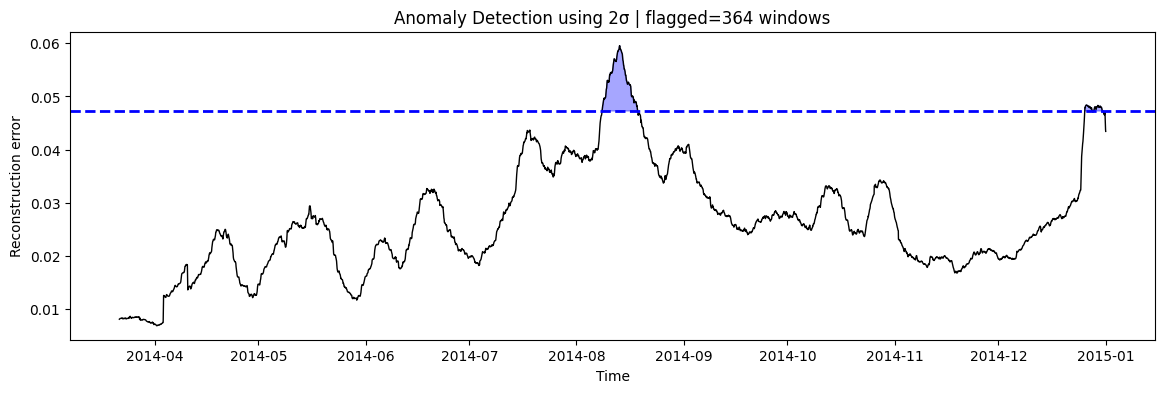

In [46]:
plt.figure(figsize=(14,4))
plt.plot(val_window_end_times, val_err_tf_clean, color="black", linewidth=1)
plt.axhline(thr_2s, color="blue", linestyle="--", linewidth=2)

plt.fill_between(
    val_window_end_times,
    val_err_tf_clean,
    thr_2s,
    where=(val_err_tf_clean >= thr_2s),
    color="blue",
    alpha=0.35
)

plt.title(f"Anomaly Detection using 2σ | flagged={(val_err_tf_clean>=thr_2s).sum()} windows")
plt.xlabel("Time")
plt.ylabel("Reconstruction error")
plt.show()

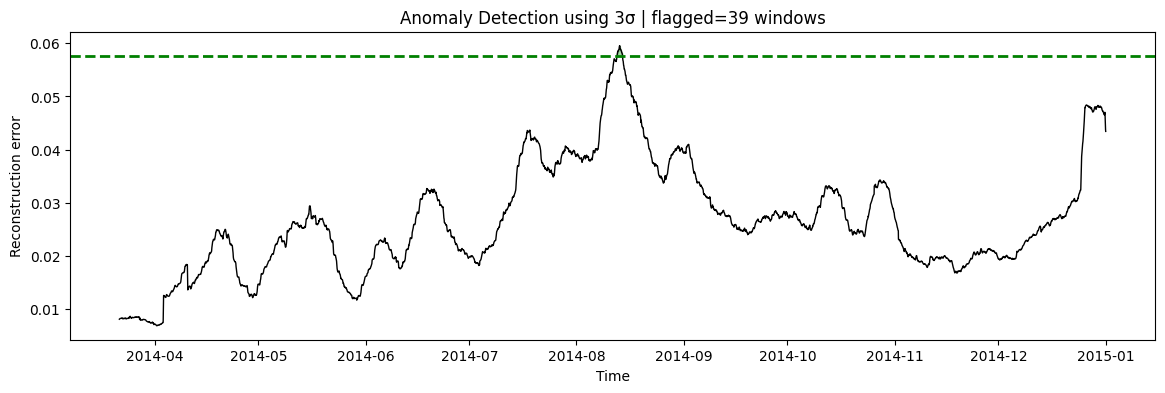

In [52]:
plt.figure(figsize=(14,4))
plt.plot(val_window_end_times, val_err_tf_clean, color="black", linewidth=1)
plt.axhline(thr_3s, color="green", linestyle="--", linewidth=2)

plt.fill_between(
    val_window_end_times,
    val_err_tf_clean,
    thr_3s,
    where=(val_err_tf_clean >= thr_3s),
    color="green",
    alpha=0.35
)

plt.title(f"Anomaly Detection using 3σ | flagged={(val_err_tf_clean>=thr_3s).sum()} windows")
plt.xlabel("Time")
plt.ylabel("Reconstruction error")
plt.show() 

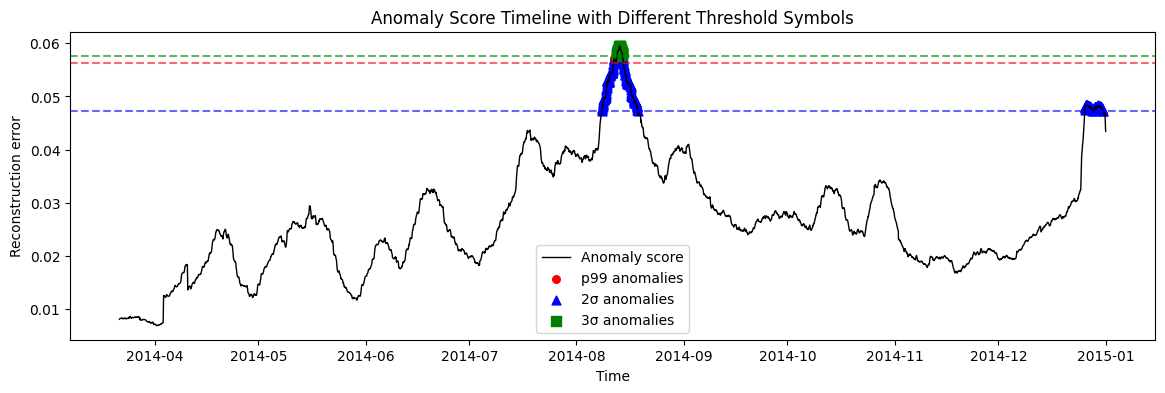

In [47]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14,4))


plt.plot(val_window_end_times, val_err_tf_clean, color="black", linewidth=1, label="Anomaly score")

# masks
mask_p99 = val_err_tf_clean >= thr_p99
mask_2s  = val_err_tf_clean >= thr_2s
mask_3s  = val_err_tf_clean >= thr_3s

# plot anomalies with different markers
plt.scatter(val_window_end_times[mask_p99], val_err_tf_clean[mask_p99],
            marker="o", color="red", s=30, label="p99 anomalies")

plt.scatter(val_window_end_times[mask_2s], val_err_tf_clean[mask_2s],
            marker="^", color="blue", s=40, label="2σ anomalies")

plt.scatter(val_window_end_times[mask_3s], val_err_tf_clean[mask_3s],
            marker="s", color="green", s=50, label="3σ anomalies")

# threshold lines
plt.axhline(thr_p99, linestyle="--", color="red", alpha=0.6)
plt.axhline(thr_2s, linestyle="--", color="blue", alpha=0.6)
plt.axhline(thr_3s, linestyle="--", color="green", alpha=0.6)

plt.title("Anomaly Score Timeline with Different Threshold Symbols")
plt.xlabel("Time")
plt.ylabel("Reconstruction error")
plt.legend()
plt.show()

In [50]:
models = [
    "Transformer AE",
    "LSTM AE",
    "VAE",
    "IsolationForest"
]

pr_auc_values = [
    pr_auc_tf,
    pr_auc_lstm,
    pr_auc_vae,
    pr_auc_iso
] 

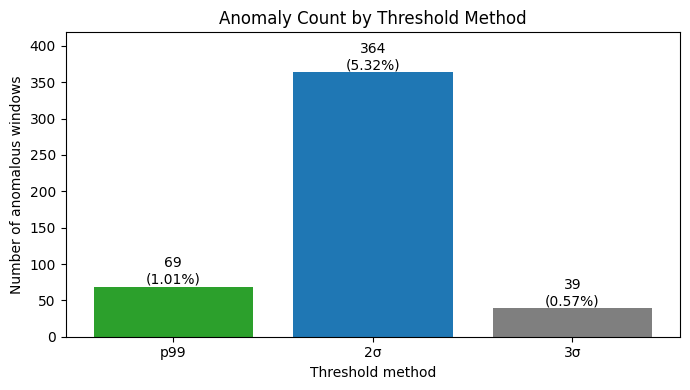

In [48]:
import matplotlib.pyplot as plt

# anomaly counts
count_p99 = (val_err_tf_clean >= thr_p99).sum()
count_2s  = (val_err_tf_clean >= thr_2s).sum()
count_3s  = (val_err_tf_clean >= thr_3s).sum()

methods = ["p99", "2σ", "3σ"]
counts  = [count_p99, count_2s, count_3s]
rates   = [c / len(val_err_tf_clean) * 100 for c in counts]

colors = ["tab:green", "tab:blue", "tab:gray"] 

plt.figure(figsize=(7,4))
bars = plt.bar(methods, counts, color=colors)

plt.title("Anomaly Count by Threshold Method")
plt.xlabel("Threshold method")
plt.ylabel("Number of anomalous windows")

for bar, c, r in zip(bars, counts, rates):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{c}\n({r:.2f}%)",
        ha="center",
        va="bottom"
    )

#  add headroom so text doesn't hit the border
plt.ylim(top=max(counts) * 1.15)

plt.tight_layout()
plt.show()

# Stage 5) - Others Models Comparison

### LSTM Autoencoder Architecture

In [30]:
class LSTMAE(nn.Module):
    def __init__(self, in_dim=30, hidden=64, bottleneck=16, num_layers=1):
        super().__init__()
        self.encoder = nn.LSTM(in_dim, hidden, num_layers=num_layers, batch_first=True)
        self.to_latent = nn.Linear(hidden, bottleneck)
        self.from_latent = nn.Linear(bottleneck, hidden)
        self.decoder = nn.LSTM(hidden, hidden, num_layers=num_layers, batch_first=True)
        self.out = nn.Linear(hidden, in_dim)

    def forward(self, x):
        h, _ = self.encoder(x)
        z = self.to_latent(h)
        h2 = self.from_latent(z)
        d, _ = self.decoder(h2)
        y = self.out(d)
        return y

### Train and Evaluate LSTM Autoencoder

In [31]:
lstm_ae = LSTMAE(in_dim=K, hidden=64, bottleneck=16, num_layers=1)
lstm_ae = train_ae(lstm_ae, train_loader, val_loader, device, epochs=20, lr=1e-3)

X_val_corrupt_lstm, y_true_lstm = inject_synthetic_anomalies(X_val, frac=0.05, seed=42)
scores_lstm = window_mse_torch(lstm_ae, X_val_corrupt_lstm, device=device, batch_size=256)
pr_auc_lstm = pr_auc_from_scores(y_true_lstm, scores_lstm)
print("LSTM AE PR-AUC:", pr_auc_lstm)

Epoch 01 | train MSE: 0.141025 | val MSE: 0.079153
Epoch 02 | train MSE: 0.039446 | val MSE: 0.051506
Epoch 03 | train MSE: 0.025931 | val MSE: 0.039524
Epoch 04 | train MSE: 0.018198 | val MSE: 0.033975
Epoch 05 | train MSE: 0.014393 | val MSE: 0.031454
Epoch 06 | train MSE: 0.012266 | val MSE: 0.028725
Epoch 07 | train MSE: 0.010775 | val MSE: 0.028252
Epoch 08 | train MSE: 0.009948 | val MSE: 0.028543
Epoch 09 | train MSE: 0.009421 | val MSE: 0.028223
Epoch 10 | train MSE: 0.008985 | val MSE: 0.027874
Epoch 11 | train MSE: 0.008672 | val MSE: 0.027445
Epoch 12 | train MSE: 0.008397 | val MSE: 0.027895
Epoch 13 | train MSE: 0.008186 | val MSE: 0.027826
Epoch 14 | train MSE: 0.007948 | val MSE: 0.028139
Epoch 15 | train MSE: 0.007798 | val MSE: 0.027804
Epoch 16 | train MSE: 0.007633 | val MSE: 0.028241
Epoch 17 | train MSE: 0.007500 | val MSE: 0.028038
Epoch 18 | train MSE: 0.007391 | val MSE: 0.028210
Epoch 19 | train MSE: 0.007281 | val MSE: 0.028408
Epoch 20 | train MSE: 0.007178 

### Variational Autoencoder (VAE) Architecture 

In [32]:
class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim=16, hidden_dim=256):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.mu = nn.Linear(hidden_dim, latent_dim)
        self.logvar = nn.Linear(hidden_dim, latent_dim)

        self.dec = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
        )

    def reparam(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.enc(x)
        mu = self.mu(h)
        logvar = self.logvar(h)
        z = self.reparam(mu, logvar)
        recon = self.dec(z)
        return recon, mu, logvar

### Train and Evaluate VAE

In [33]:
def vae_loss(recon, x, mu, logvar, beta=1e-3):
    recon_loss = torch.mean((recon - x) ** 2)
    kld = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kld


def train_vae(model, X_train, X_val, device, epochs=20, lr=1e-3, batch_size=256, beta=1e-3):
    model.to(device)
    opt = optim.Adam(model.parameters(), lr=lr)

    Xtr = X_train.reshape(X_train.shape[0], -1)
    Xva = X_val.reshape(X_val.shape[0], -1)

    def run(Xnp, train=True):
        model.train(train)
        total, n = 0.0, 0
        for i in range(0, len(Xnp), batch_size):
            xb = torch.from_numpy(Xnp[i:i+batch_size]).float().to(device)
            if train:
                opt.zero_grad()
            recon, mu, logvar = model(xb)
            loss = vae_loss(recon, xb, mu, logvar, beta=beta)
            if train:
                loss.backward()
                opt.step()
            total += loss.item() * xb.size(0)
            n += xb.size(0)
        return total / n

    for ep in range(1, epochs+1):
        tr = run(Xtr, True)
        va = run(Xva, False)
        print(f"Epoch {ep:02d} | train loss: {tr:.6f} | val loss: {va:.6f}")

    return model


def vae_window_mse(model, X_np, device, batch_size=256):
    model.eval()
    Xf = X_np.reshape(X_np.shape[0], -1)
    errs = []
    with torch.no_grad():
        for i in range(0, len(Xf), batch_size):
            xb = torch.from_numpy(Xf[i:i+batch_size]).float().to(device)
            recon, mu, logvar = model(xb)
            e = torch.mean((recon - xb) ** 2, dim=1)  # per-window
            errs.append(e.detach().cpu().numpy())
    return np.concatenate(errs)

vae_in_dim = seq_len * K
vae = VAE(input_dim=vae_in_dim, latent_dim=16, hidden_dim=256)
vae = train_vae(vae, X_train, X_val, device, epochs=20, lr=1e-3, batch_size=256, beta=1e-3)

X_val_corrupt_vae, y_true_vae = inject_synthetic_anomalies(X_val, frac=0.05, seed=42)
scores_vae = vae_window_mse(vae, X_val_corrupt_vae, device=device, batch_size=256)
pr_auc_vae = pr_auc_from_scores(y_true_vae, scores_vae)
print("VAE PR-AUC:", pr_auc_vae)

Epoch 01 | train loss: 0.463573 | val loss: 0.288398
Epoch 02 | train loss: 0.421493 | val loss: 0.369664
Epoch 03 | train loss: 0.416366 | val loss: 0.329069
Epoch 04 | train loss: 0.488272 | val loss: 0.319048
Epoch 05 | train loss: 0.371030 | val loss: 0.305294
Epoch 06 | train loss: 0.310484 | val loss: 0.326929
Epoch 07 | train loss: 0.282583 | val loss: 0.330538
Epoch 08 | train loss: 0.278662 | val loss: 0.324856
Epoch 09 | train loss: 0.259897 | val loss: 0.348302
Epoch 10 | train loss: 0.245797 | val loss: 0.333300
Epoch 11 | train loss: 0.253702 | val loss: 0.307655
Epoch 12 | train loss: 0.257284 | val loss: 0.376453
Epoch 13 | train loss: 0.237774 | val loss: 0.236546
Epoch 14 | train loss: 0.220031 | val loss: 0.328342
Epoch 15 | train loss: 0.224612 | val loss: 0.313022
Epoch 16 | train loss: 0.206973 | val loss: 0.347514
Epoch 17 | train loss: 0.220649 | val loss: 0.324795
Epoch 18 | train loss: 0.217339 | val loss: 0.256967
Epoch 19 | train loss: 0.200983 | val loss: 0.

### Isolation Forest Baseline Evaluation

In [34]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat   = X_val.reshape(X_val.shape[0], -1)

iso = IsolationForest(
    n_estimators=300,
    contamination=0.05,  
    random_state=42,
    n_jobs=-1
)
iso.fit(X_train_flat)

X_val_corrupt_iso, y_true_iso = inject_synthetic_anomalies(X_val, frac=0.05, seed=42)
X_val_corrupt_iso_flat = X_val_corrupt_iso.reshape(X_val_corrupt_iso.shape[0], -1)

scores_iso = -iso.decision_function(X_val_corrupt_iso_flat) 
pr_auc_iso = pr_auc_from_scores(y_true_iso, scores_iso)
print("IsolationForest PR-AUC:", pr_auc_iso)

IsolationForest PR-AUC: 0.06243480992929393


# Stage 6) - Results and Reporting

### Model Performance Comparison (PR-AUC Bar Plot)

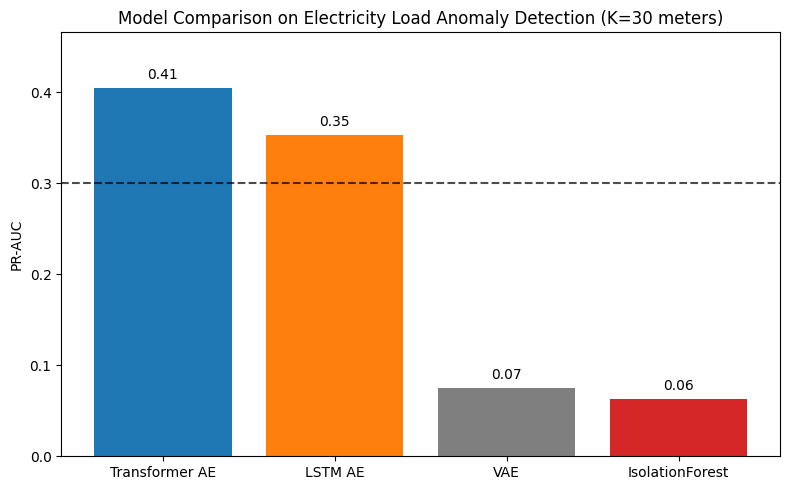

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
bars = plt.bar(models, pr_auc_values, 
               color=["tab:blue", "tab:orange", "tab:gray", "tab:red"])

plt.axhline(0.30, linestyle="--", color="black", alpha=0.7)
plt.ylabel("PR-AUC")
plt.title("Model Comparison on Electricity Load Anomaly Detection (K=30 meters)")

for bar, v in zip(bars, pr_auc_values):
    plt.text(bar.get_x() + bar.get_width()/2,
             v + 0.01,
             f"{v:.2f}",
             ha="center")

plt.ylim(0, max(pr_auc_values) * 1.15)
plt.tight_layout()
plt.show() 

### Final results Summary table

In [36]:
results = {
    "Transformer AE (K=30)": float(pr_auc_tf),
    "LSTM AE (K=30)": float(pr_auc_lstm) if "pr_auc_lstm" in globals() else None,
    "VAE (K=30)": float(pr_auc_vae) if "pr_auc_vae" in globals() else None,
    "IsolationForest (K=30)": float(pr_auc_iso) if "pr_auc_iso" in globals() else None,
}
results

{'Transformer AE (K=30)': 0.4051520611704121,
 'LSTM AE (K=30)': 0.3530680174662801,
 'VAE (K=30)': 0.07485294833228831,
 'IsolationForest (K=30)': 0.06243480992929393}

In [37]:
import pandas as pd

results_df = (
    pd.DataFrame(list(results.items()), columns=["Model", "PR-AUC"])
      .dropna()
      .sort_values("PR-AUC", ascending=False)
      .reset_index(drop=True)
)

results_df.style.format({"PR-AUC": "{:.3f}"}) \
    .set_caption("Model Comparison on Electricity Load Anomaly Detection (K = 30)")

,Model,PR-AUC
0,Transformer AE (K=30),0.405
1,LSTM AE (K=30),0.353
2,VAE (K=30),0.075
3,IsolationForest (K=30),0.062


### Check the PR-AUC Target score of the models

In [38]:
import pandas as pd

results = {
    "Transformer AE (K=30)": float(pr_auc_tf),
    "LSTM AE (K=30)": float(pr_auc_lstm),
    "VAE (K=30)": float(pr_auc_vae),
    "IsolationForest (K=30)": float(pr_auc_iso),
}

results_df = (
    pd.DataFrame(list(results.items()), columns=["Model", "PR-AUC"])
      .sort_values("PR-AUC", ascending=False)
      .reset_index(drop=True)
)

results_df["PR-AUC"] = results_df["PR-AUC"].round(3)
results_df["Meets Target (PR-AUC ≥ 0.30)"] = results_df["PR-AUC"] >= 0.30

results_df.style.format({"PR-AUC": "{:.3f}"}) \
                .set_caption("Model Comparison on Electricity Load Anomaly Detection (K = 30)") \
                .highlight_max(subset=["PR-AUC"], color="red")

,Model,PR-AUC,Meets Target (PR-AUC ≥ 0.30)
0,Transformer AE (K=30),0.405,True
1,LSTM AE (K=30),0.353,True
2,VAE (K=30),0.075,False
3,IsolationForest (K=30),0.062,False


# Stage 7) - Save files for the dashboard 

### Save timestamps

In [39]:
import numpy as np
import pandas as pd

# Save timestamps
pd.Series(val_window_end_times).to_pickle("val_times.pkl")

### Save transformer anomaly scores (clean validation)

In [40]:
# Save Transformer anomaly scores (clean validation)
np.save("val_err_transformer.npy", val_err_tf_clean.astype(np.float32))

### Save meters list (K=30)

In [41]:
# Save meters list (K=30)
np.save("meters_k30.npy", np.array(meters, dtype=object))

### Save IsolationForest scores on clean validation for overlay

In [42]:
if "iso" in globals() and "X_val_flat" in globals():
    scores_if_clean = (-iso.decision_function(X_val_flat)).astype(np.float32)
    np.save("val_err_isoforest.npy", scores_if_clean)
    print("Saved: val_err_isoforest.npy")
else:
    print("IsolationForest clean scores not saved (iso or X_val_flat not found).")

print("Saved: val_times.pkl, val_err_transformer.npy, meters_k30.npy")

Saved: val_err_isoforest.npy
Saved: val_times.pkl, val_err_transformer.npy, meters_k30.npy


# Task 3 (Extended task)

## Bottleneck Dimensionality Ablation

### Setup

In [57]:
# -- Setup --
import time

bottlenecks = [4, 8, 16, 32, 64]

results = []

In [58]:
X_val_corrupt, y_true = inject_synthetic_anomalies(X_val, frac=0.05, seed=42)

### Training loop

In [59]:

# -- Training loop --
trained_models_by_bottleneck = {}

for b in bottlenecks:
    print(f"\n===== Bottleneck = {b} =====")

    model = TransformerAE(
        seq_len=168,
        in_dim=K,
        d_model=64,
        nhead=4,
        num_layers=2,
        bottleneck=b,
        dropout=0.1
    ).to(device)

    start_time = time.time()


    train_ae(model, train_loader, val_loader, device, epochs=10)

    trained_models_by_bottleneck[b] = model

    train_time = time.time() - start_time
    val_err_clean = window_mse_torch(model, X_val, device)


    val_err_corrupt = window_mse_torch(model, X_val_corrupt, device) 

    pr_auc = pr_auc_from_scores(y_true, val_err_corrupt)

    param_count = sum(p.numel() for p in model.parameters())

    model_size_mb = param_count * 4 / (1024 ** 2) 

    print(f"PR-AUC: {pr_auc:.4f} | Train time: {train_time:.2f}s")

    results.append({
        "bottleneck": b,
        "pr_auc": pr_auc,
        "recon_error": val_err_clean.mean(),
        "train_time": train_time,
        "params": param_count,
        "model_size_mb": model_size_mb
})


===== Bottleneck = 4 =====
Epoch 01 | train MSE: 0.129243 | val MSE: 0.090761
Epoch 02 | train MSE: 0.049396 | val MSE: 0.078841
Epoch 03 | train MSE: 0.039182 | val MSE: 0.073836
Epoch 04 | train MSE: 0.034971 | val MSE: 0.074075
Epoch 05 | train MSE: 0.032231 | val MSE: 0.073847
Epoch 06 | train MSE: 0.030538 | val MSE: 0.073518
Epoch 07 | train MSE: 0.028994 | val MSE: 0.074643
Epoch 08 | train MSE: 0.027810 | val MSE: 0.073860
Epoch 09 | train MSE: 0.026967 | val MSE: 0.074562
Epoch 10 | train MSE: 0.026081 | val MSE: 0.070111
PR-AUC: 0.3309 | Train time: 335.15s

===== Bottleneck = 8 =====
Epoch 01 | train MSE: 0.118236 | val MSE: 0.068983
Epoch 02 | train MSE: 0.036335 | val MSE: 0.055346
Epoch 03 | train MSE: 0.027718 | val MSE: 0.053925
Epoch 04 | train MSE: 0.023245 | val MSE: 0.050958
Epoch 05 | train MSE: 0.020665 | val MSE: 0.049272
Epoch 06 | train MSE: 0.019053 | val MSE: 0.048731
Epoch 07 | train MSE: 0.017805 | val MSE: 0.051429
Epoch 08 | train MSE: 0.016917 | val MSE

### Focused Bottleneck Comparison (2 representative models)

In [60]:
bottlenecks_focus = [16, 64]
focus_results = []

for b in bottlenecks_focus:
    print(f"\n===== Focused bottleneck experiment: {b} =====")

    model_focus = TransformerAE(
        seq_len=168,
        in_dim=K,
        d_model=64,
        nhead=4,
        num_layers=2,
        bottleneck=b,
        dropout=0.1
    ).to(device)

    start_time = time.time()

    train_ae(model_focus, train_loader, val_loader, device, epochs=5, lr=1e-3)

    train_time = time.time() - start_time

    val_err_clean_focus = window_mse_torch(model_focus, X_val, device)

    X_val_corrupt_focus, y_true_focus = inject_synthetic_anomalies(X_val, frac=0.05, seed=42)
    val_err_corrupt_focus = window_mse_torch(model_focus, X_val_corrupt_focus, device)

    pr_auc_focus = pr_auc_from_scores(y_true_focus, val_err_corrupt_focus)

    param_count_focus = sum(p.numel() for p in model_focus.parameters())
    model_size_mb_focus = param_count_focus * 4 / (1024 ** 2)

    focus_results.append({
        "bottleneck": b,
        "pr_auc": pr_auc_focus,
        "recon_error": float(val_err_clean_focus.mean()),
        "train_time": train_time,
        "params": param_count_focus,
        "model_size_mb": model_size_mb_focus
    })

focus_df = pd.DataFrame(focus_results).sort_values("bottleneck").reset_index(drop=True)

print("\nStage 8B — Focused comparison results")
print(focus_df)


===== Focused bottleneck experiment: 16 =====
Epoch 01 | train MSE: 0.097252 | val MSE: 0.043768
Epoch 02 | train MSE: 0.021263 | val MSE: 0.032613
Epoch 03 | train MSE: 0.013922 | val MSE: 0.031060
Epoch 04 | train MSE: 0.011004 | val MSE: 0.030807
Epoch 05 | train MSE: 0.009417 | val MSE: 0.029377

===== Focused bottleneck experiment: 64 =====
Epoch 01 | train MSE: 0.079737 | val MSE: 0.032574
Epoch 02 | train MSE: 0.012152 | val MSE: 0.013324
Epoch 03 | train MSE: 0.004827 | val MSE: 0.005186
Epoch 04 | train MSE: 0.002376 | val MSE: 0.002380
Epoch 05 | train MSE: 0.001394 | val MSE: 0.001358

Stage 8B — Focused comparison results
   bottleneck    pr_auc  recon_error  train_time   params  model_size_mb
0          16  0.349775     0.029377  169.156237  1130670       4.313164
1          64  0.397158     0.001358  168.435212  1136862       4.336784


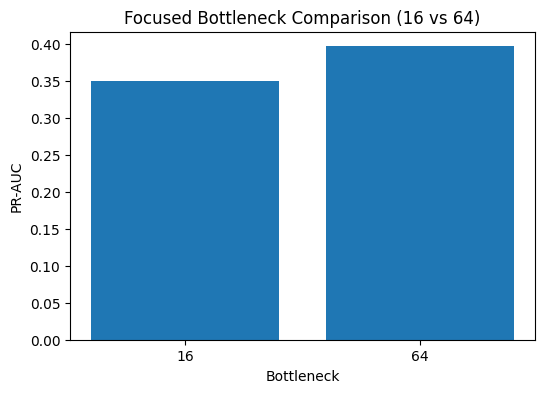

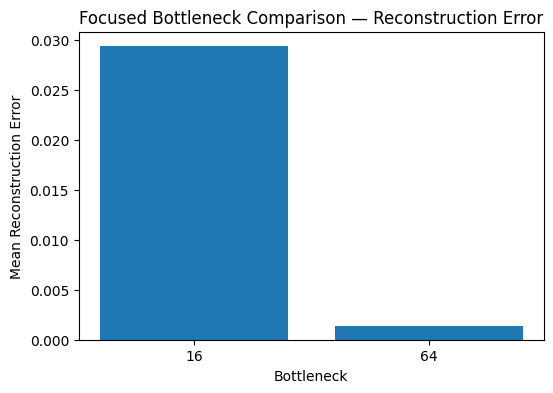

In [61]:
plt.figure(figsize=(6,4))
plt.bar(focus_df["bottleneck"].astype(str), focus_df["pr_auc"])
plt.title("Focused Bottleneck Comparison (16 vs 64)")
plt.xlabel("Bottleneck")
plt.ylabel("PR-AUC")
plt.show()

plt.figure(figsize=(6,4))
plt.bar(focus_df["bottleneck"].astype(str), focus_df["recon_error"])
plt.title("Focused Bottleneck Comparison — Reconstruction Error")
plt.xlabel("Bottleneck")
plt.ylabel("Mean Reconstruction Error")
plt.show()

### Results table

In [62]:
# -- Results table --
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("bottleneck").reset_index(drop=True)

ref_size = results_df["model_size_mb"].max()
results_df["compression_ratio"] = ref_size / results_df["model_size_mb"]
results_df["size_reduction_pct"] = 100 * (1 - results_df["model_size_mb"] / ref_size)
results_df.to_csv("stage8_bottleneck_results.csv", index=False)

In [63]:
results_df

,bottleneck,pr_auc,recon_error,train_time,params,model_size_mb,compression_ratio,size_reduction_pct
0,4,0.330880,0.070111,335.151319,1129122,4.307259,1.006855,0.680821
1,8,0.327543,0.049637,335.116916,1129638,4.309227,1.006395,0.635433
2,16,0.317387,0.028915,334.232778,1130670,4.313164,1.005476,0.544657
3,32,0.371246,0.001068,335.088389,1132734,4.321037,1.003644,0.363105
4,64,0.366500,0.001760,694.953194,1136862,4.336784,1.000000,0.000000


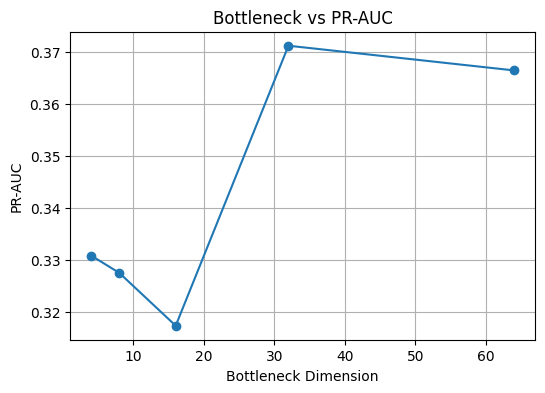

In [64]:
# -- Plot: Bottleneck vs PR-AUC --
plt.figure(figsize=(6,4))
plt.plot(results_df["bottleneck"], results_df["pr_auc"], marker='o')

plt.title("Bottleneck vs PR-AUC")
plt.xlabel("Bottleneck Dimension")
plt.ylabel("PR-AUC")

plt.grid()
plt.show()

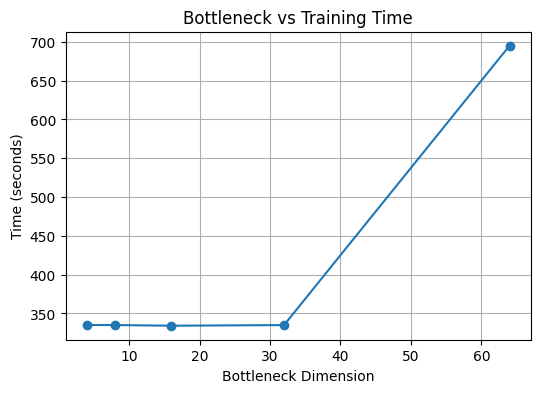

In [65]:
# -- Plot Bottleneck vs Train Time --
plt.figure(figsize=(6,4))
plt.plot(results_df["bottleneck"], results_df["train_time"], marker='o')

plt.title("Bottleneck vs Training Time")
plt.xlabel("Bottleneck Dimension")
plt.ylabel("Time (seconds)")

plt.grid()
plt.show()

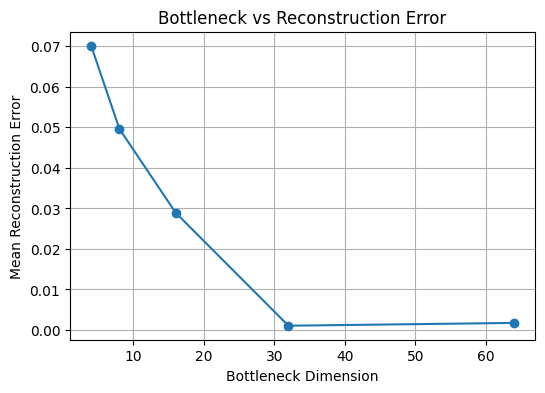

In [66]:
# -- Plot Bottleneck vs Reconstruction Error --
plt.figure(figsize=(6,4))
plt.plot(results_df["bottleneck"], results_df["recon_error"], marker='o')

plt.title("Bottleneck vs Reconstruction Error")
plt.xlabel("Bottleneck Dimension")
plt.ylabel("Mean Reconstruction Error")

plt.grid()
plt.show()

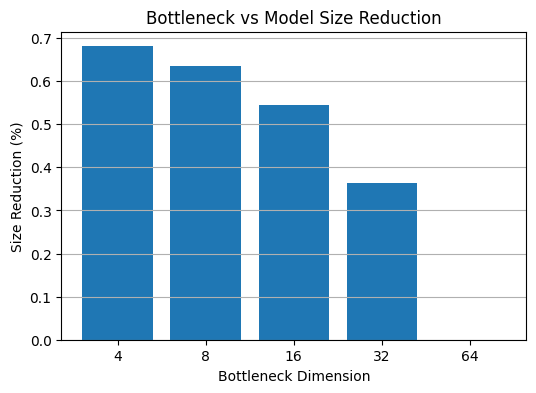

In [67]:
# -- Plot Bottleneck vs Model Size Reduction --
plt.figure(figsize=(6,4))
plt.bar(results_df["bottleneck"].astype(str), results_df["size_reduction_pct"])
plt.title("Bottleneck vs Model Size Reduction")
plt.xlabel("Bottleneck Dimension")
plt.ylabel("Size Reduction (%)")
plt.grid(axis="y")
plt.show()

### Best model & Sweet spot

In [68]:
# Best model
best_row = results_df.loc[results_df["pr_auc"].idxmax()]
print("Best model:")
print(best_row)

# Sweet spot (within 5% of best)
best_pr = results_df["pr_auc"].max() ### ...
threshold = best_pr * 0.95

sweet_candidates = results_df[results_df["pr_auc"] >= threshold].sort_values("bottleneck")
sweet_spot = sweet_candidates.iloc[0] ### 

print("\nSweet spot bottleneck:", sweet_spot["bottleneck"])

Best model:
bottleneck            3.200000e+01
pr_auc                3.712456e-01
recon_error           1.067946e-03
train_time            3.350884e+02
params                1.132734e+06
model_size_mb         4.321037e+00
compression_ratio     1.003644e+00
size_reduction_pct    3.631048e-01
Name: 3, dtype: float64

Sweet spot bottleneck: 32.0


In [69]:
results_df["pr_auc_drop_pct"] = 100 * (best_pr - results_df["pr_auc"]) / best_pr

print(results_df[[
    "bottleneck",
    "pr_auc",
    "pr_auc_drop_pct",
    "recon_error",
    "train_time",
    "model_size_mb",
    "size_reduction_pct"
]])

   bottleneck    pr_auc  pr_auc_drop_pct  recon_error  train_time  \
0           4  0.330880        10.873007     0.070111  335.151319   
1           8  0.327543        11.771984     0.049637  335.116916   
2          16  0.317387        14.507498     0.028915  334.232778   
3          32  0.371246         0.000000     0.001068  335.088389   
4          64  0.366500         1.278181     0.001760  694.953194   

   model_size_mb  size_reduction_pct  
0       4.307259            0.680821  
1       4.309227            0.635433  
2       4.313164            0.544657  
3       4.321037            0.363105  
4       4.336784            0.000000  


In [70]:
# -- Save results --
results_df.to_csv("bottleneck_ablation_results.csv", index=False)
print("Results saved")

Results saved


### MINE - Mutual Information Neural Estimation

In [71]:
# Add MINE class
import torch.nn as nn
import torch.optim as optim

class MINE(nn.Module):
    def __init__(self, x_dim, z_dim, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(x_dim + z_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x, z):
        return self.net(torch.cat([x, z], dim=1))

In [72]:
# Add Function
def collect_latents(model, X_np, device, max_samples=1500, batch_size=128):
    model.eval()
    idx = np.random.choice(len(X_np), size=min(max_samples, len(X_np)), replace=False)
    X_sub = X_np[idx]

    xs, zs = [], []

    with torch.no_grad():
        for i in range(0, len(X_sub), batch_size):
            xb = torch.tensor(X_sub[i:i+batch_size], dtype=torch.float32).to(device)
            zb = model.encode(xb)

            xs.append(xb.cpu())
            zs.append(zb.cpu())

    X_cat = torch.cat(xs, dim=0)
    Z_cat = torch.cat(zs, dim=0)

    X_flat = X_cat.reshape(X_cat.shape[0], -1)
    Z_flat = Z_cat.reshape(Z_cat.shape[0], -1)

    return X_flat, Z_flat

In [73]:
# Add MINE train function
def estimate_mi_mine(X_flat, Z_flat, device, epochs=100, batch_size=128):
    X_flat = X_flat.to(device)
    Z_flat = Z_flat.to(device)

    mine = MINE(X_flat.shape[1], Z_flat.shape[1]).to(device)
    opt = optim.Adam(mine.parameters(), lr=1e-3)

    n = X_flat.shape[0]

    for epoch in range(epochs):
        perm = torch.randperm(n, device=device)

        for i in range(0, n, batch_size):
            idx = perm[i:i+batch_size]
            x = X_flat[idx]
            z = Z_flat[idx]

            z_shuffle = z[torch.randperm(len(z), device=device)]

            joint = mine(x, z)
            marginal = mine(x, z_shuffle)

            loss = -(torch.mean(joint) - torch.log(torch.mean(torch.exp(marginal)) + 1e-8))

            opt.zero_grad()
            loss.backward()
            opt.step()

    mi_est = (torch.mean(joint) - torch.log(torch.mean(torch.exp(marginal)) + 1e-8)).item()
    return mi_est

In [74]:
# Run MINE for each model 
mi_results = []

for b in trained_models_by_bottleneck:
    model_b = trained_models_by_bottleneck[b]

    X_flat, Z_flat = collect_latents(model_b, X_val, device)
    mi_est = estimate_mi_mine(X_flat, Z_flat, device)

    mi_results.append({
        "bottleneck": b,
        "mi_estimate": mi_est
    })

mi_df = pd.DataFrame(mi_results).sort_values("bottleneck")

results_df = results_df.merge(mi_df, on="bottleneck", how="left")

print(results_df)

   bottleneck    pr_auc  recon_error  train_time   params  model_size_mb  \
0           4  0.330880     0.070111  335.151319  1129122       4.307259   
1           8  0.327543     0.049637  335.116916  1129638       4.309227   
2          16  0.317387     0.028915  334.232778  1130670       4.313164   
3          32  0.371246     0.001068  335.088389  1132734       4.321037   
4          64  0.366500     0.001760  694.953194  1136862       4.336784   

   compression_ratio  size_reduction_pct  pr_auc_drop_pct  mi_estimate  
0           1.006855            0.680821        10.873007     3.887878  
1           1.006395            0.635433        11.771984    10.402202  
2           1.005476            0.544657        14.507498     2.073671  
3           1.003644            0.363105         0.000000     6.545630  
4           1.000000            0.000000         1.278181     5.918187  


In [75]:
# Keep only one row per bottleneck
results_df = results_df.sort_values(["bottleneck", "pr_auc"], ascending=[True, False])
results_df = results_df.drop_duplicates(subset="bottleneck", keep="first").reset_index(drop=True)

print(results_df)

   bottleneck    pr_auc  recon_error  train_time   params  model_size_mb  \
0           4  0.330880     0.070111  335.151319  1129122       4.307259   
1           8  0.327543     0.049637  335.116916  1129638       4.309227   
2          16  0.317387     0.028915  334.232778  1130670       4.313164   
3          32  0.371246     0.001068  335.088389  1132734       4.321037   
4          64  0.366500     0.001760  694.953194  1136862       4.336784   

   compression_ratio  size_reduction_pct  pr_auc_drop_pct  mi_estimate  
0           1.006855            0.680821        10.873007     3.887878  
1           1.006395            0.635433        11.771984    10.402202  
2           1.005476            0.544657        14.507498     2.073671  
3           1.003644            0.363105         0.000000     6.545630  
4           1.000000            0.000000         1.278181     5.918187  


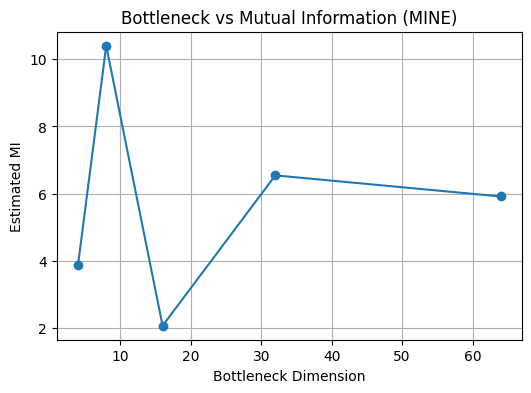

In [76]:
# Plot MI
plt.figure(figsize=(6,4))
plt.plot(results_df["bottleneck"], results_df["mi_estimate"], marker="o")
plt.title("Bottleneck vs Mutual Information (MINE)")
plt.xlabel("Bottleneck Dimension")
plt.ylabel("Estimated MI")
plt.grid(True)
plt.show()

In [77]:
# Summary

best_row = results_df.sort_values("pr_auc", ascending=False).iloc[0]

best_pr = results_df["pr_auc"].max()
threshold = best_pr * 0.95
sweet_candidates = results_df[results_df["pr_auc"] >= threshold].sort_values("bottleneck")
sweet_spot = sweet_candidates.iloc[0]

print("\nTask 3 Final Summary")
print("-" * 40)
print(f"Best bottleneck: {int(best_row['bottleneck'])}")
print(f"Best PR-AUC: {best_row['pr_auc']:.4f}")
print(f"Sweet spot bottleneck: {int(sweet_spot['bottleneck'])}")
print(f"Sweet spot PR-AUC: {sweet_spot['pr_auc']:.4f}")
print(f"Size reduction: {sweet_spot['size_reduction_pct']:.2f}%")
print(f"Mutual information at sweet spot: {sweet_spot['mi_estimate']:.4f}")


Task 3 Final Summary
----------------------------------------
Best bottleneck: 32
Best PR-AUC: 0.3712
Sweet spot bottleneck: 32
Sweet spot PR-AUC: 0.3712
Size reduction: 0.36%
Mutual information at sweet spot: 6.5456


In [78]:
results_df.to_csv("bottleneck_ablation_results_final.csv", index=False)
print("Saved: bottleneck_ablation_results_final.csv")

Saved: bottleneck_ablation_results_final.csv


# Task 2: Reconstruction Error Saliency (Extended)

### Select Anomalous Window

In [79]:
# Use best model from Stage 8
best_bottleneck = int(results_df.sort_values("pr_auc", ascending=False).iloc[0]["bottleneck"])
best_model = trained_models_by_bottleneck[best_bottleneck]
best_model.eval()

print("Using bottleneck:", best_bottleneck)

# Pick top anomaly index from validation
val_err_best = window_mse_torch(best_model, X_val, device)
idx = int(np.argmax(val_err_best))

print("Selected anomaly index:", idx)
print("Selected anomaly score:", float(val_err_best[idx]))

Using bottleneck: 32
Selected anomaly index: 3423
Selected anomaly score: 0.004413398914039135


### Compute Saliency

In [80]:
# Take one anomalous window
xb = torch.tensor(X_val[idx:idx+1], dtype=torch.float32, device=device, requires_grad=True)

# Forward
pred = best_model(xb)

# Reconstruction loss
loss = torch.mean((pred - xb) ** 2)

# Backprop to input
best_model.zero_grad()
loss.backward()

# Saliency: absolute gradient wrt input
saliency = xb.grad.abs().detach().cpu().numpy()[0]   # shape: (168, K)

print("Saliency shape:", saliency.shape)

Saliency shape: (168, 30)


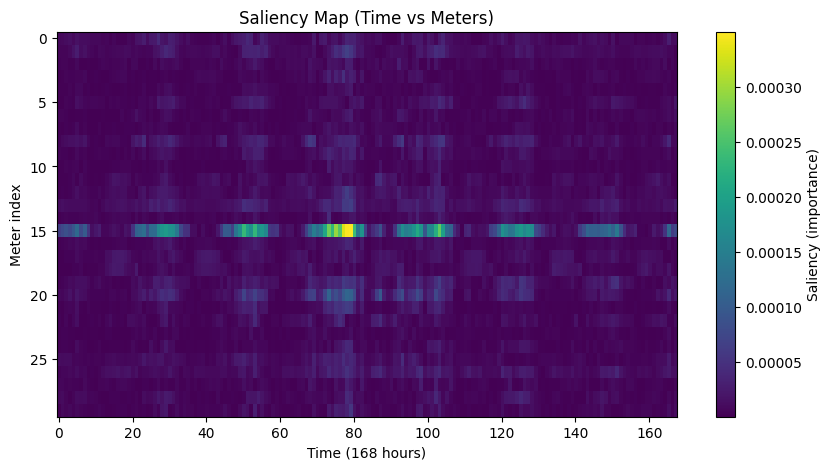

In [81]:
# Saliency Visualization
plt.figure(figsize=(10,5))

plt.imshow(saliency.T, aspect='auto')
plt.colorbar(label="Saliency (importance)")

plt.title("Saliency Map (Time vs Meters)")
plt.xlabel("Time (168 hours)")
plt.ylabel("Meter index")

plt.show()

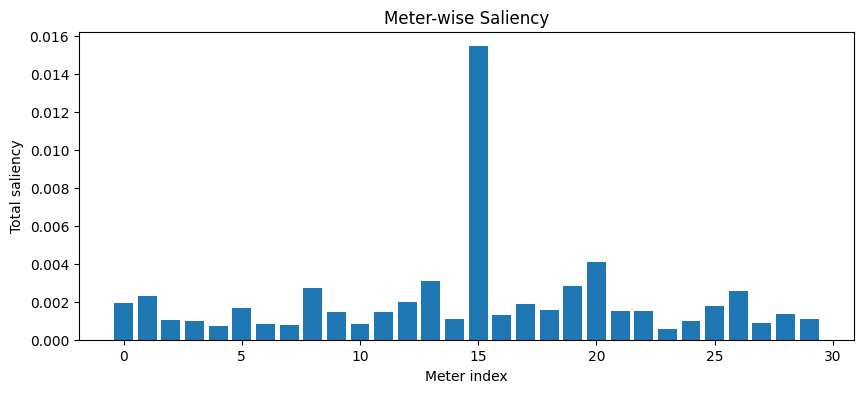

Top 5 important meters: [15, 20, 13, 19, 8]
Top 5 meter saliency values: [0.01544115 0.00409996 0.00309025 0.00284571 0.00270041]


In [82]:
meter_importance = saliency.sum(axis=0)

plt.figure(figsize=(10, 4))
plt.bar(range(len(meter_importance)), meter_importance)
plt.title("Meter-wise Saliency")
plt.xlabel("Meter index")
plt.ylabel("Total saliency")
plt.show()

top_meter_idx = np.argsort(meter_importance)[::-1][:5]
print("Top 5 important meters:", top_meter_idx.tolist())
print("Top 5 meter saliency values:", meter_importance[top_meter_idx])

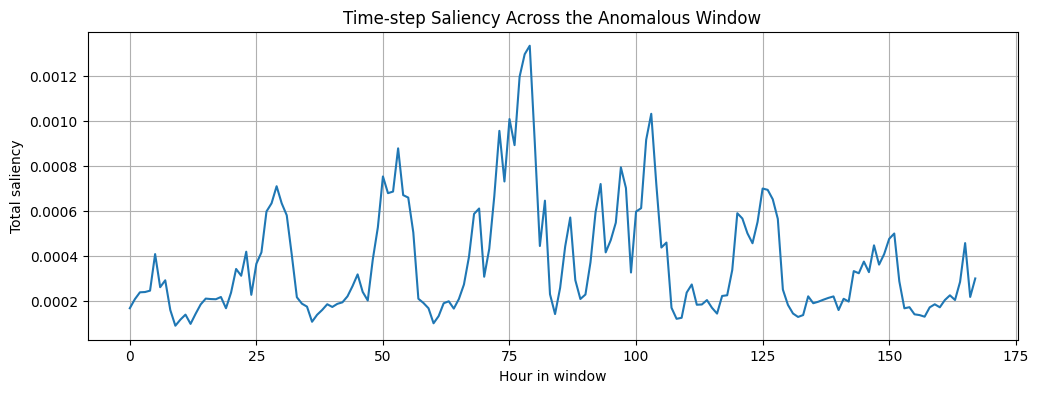

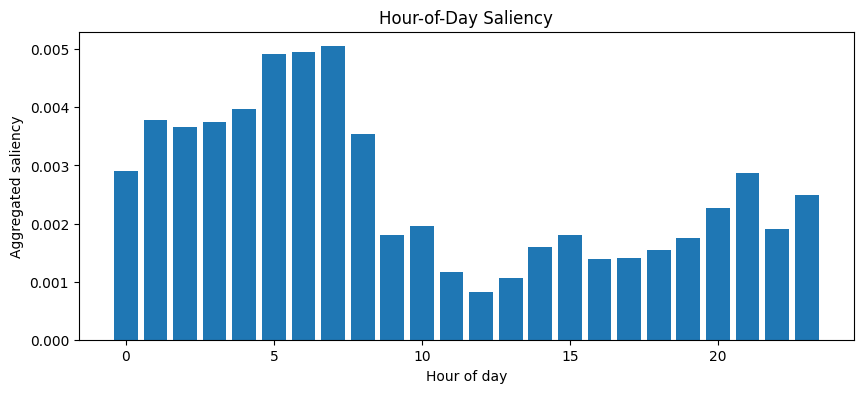

Top 5 anomalous hours of day: [7, 6, 5, 4, 1]
Top 5 hour saliency values: [0.00504791 0.00494644 0.00491108 0.00396451 0.00378769]


In [83]:
# Temporal saliency across the 168-hour window
time_importance = saliency.sum(axis=1)

plt.figure(figsize=(12, 4))
plt.plot(time_importance)
plt.title("Time-step Saliency Across the Anomalous Window")
plt.xlabel("Hour in window")
plt.ylabel("Total saliency")
plt.grid(True)
plt.show()

# Hour-of-day aggregation (168 hours = 7 days * 24 hours)
hour_of_day_saliency = np.zeros(24)
for t in range(saliency.shape[0]):
    hour_of_day_saliency[t % 24] += saliency[t].sum()

plt.figure(figsize=(10, 4))
plt.bar(range(24), hour_of_day_saliency)
plt.title("Hour-of-Day Saliency")
plt.xlabel("Hour of day")
plt.ylabel("Aggregated saliency")
plt.show()

top_hours = np.argsort(hour_of_day_saliency)[::-1][:5]
print("Top 5 anomalous hours of day:", top_hours.tolist())
print("Top 5 hour saliency values:", hour_of_day_saliency[top_hours])

### Cross meter analysis

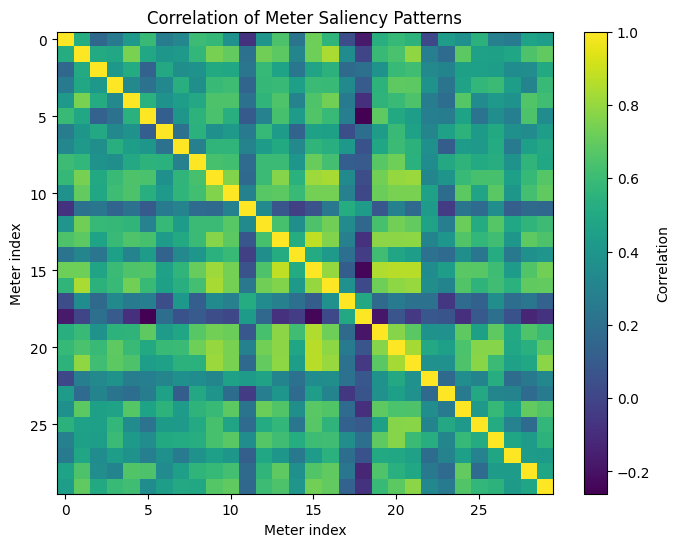

In [84]:
# Correlation of saliency patterns across meters
saliency_meter_corr = np.corrcoef(saliency.T)

plt.figure(figsize=(8, 6))
plt.imshow(saliency_meter_corr, aspect='auto')
plt.colorbar(label="Correlation")
plt.title("Correlation of Meter Saliency Patterns")
plt.xlabel("Meter index")
plt.ylabel("Meter index")
plt.show()

### Root cause Summary

In [85]:
# Task 2 Root Cause Summary
top_time_idx = np.argsort(time_importance)[::-1][:10]

print("\nTask 2 Root Cause Summary")
print("-" * 40)
print("Anomalous window index:", idx)
print("Top contributing meters:", top_meter_idx.tolist())
print("Top contributing hours in window:", top_time_idx.tolist())
print("Top anomalous hours of day:", top_hours.tolist())
print("Interpretation: the anomaly is concentrated in a small set of meters and time steps with the largest reconstruction sensitivity.")


Task 2 Root Cause Summary
----------------------------------------
Anomalous window index: 3423
Top contributing meters: [15, 20, 13, 19, 8]
Top contributing hours in window: [79, 78, 77, 103, 75, 73, 102, 80, 76, 53]
Top anomalous hours of day: [7, 6, 5, 4, 1]
Interpretation: the anomaly is concentrated in a small set of meters and time steps with the largest reconstruction sensitivity.


### Top Anomalies

In [86]:
# 9F - Bonus: Top Anomalies

# Top 3 indices
top_anomaly_indices = np.argsort(val_err_best)[-3:][::-1]
print("Top 3 anomaly indices:", top_anomaly_indices.tolist())
print("Top 3 anomaly scores:", val_err_best[top_anomaly_indices])

Top 3 anomaly indices: [3423, 3424, 3443]
Top 3 anomaly scores: [0.0044134  0.00441274 0.0044056 ]


In [87]:
# -- Save these files for dashboard purpose (stage 9) --
np.save("artifacts/saliency_map.npy", saliency)
np.save("artifacts/meter_importance.npy", meter_importance)
np.save("artifacts/hour_of_day_saliency.npy", hour_of_day_saliency)
np.save("artifacts/time_importance.npy", time_importance)
np.save("artifacts/top_meter_idx.npy", top_meter_idx)

# Task 4: Seasonal Decomposition & Anomaly Interaction (Extended Task)

### STL Decomposition of a Selected Meter

Selected meter: MT_362


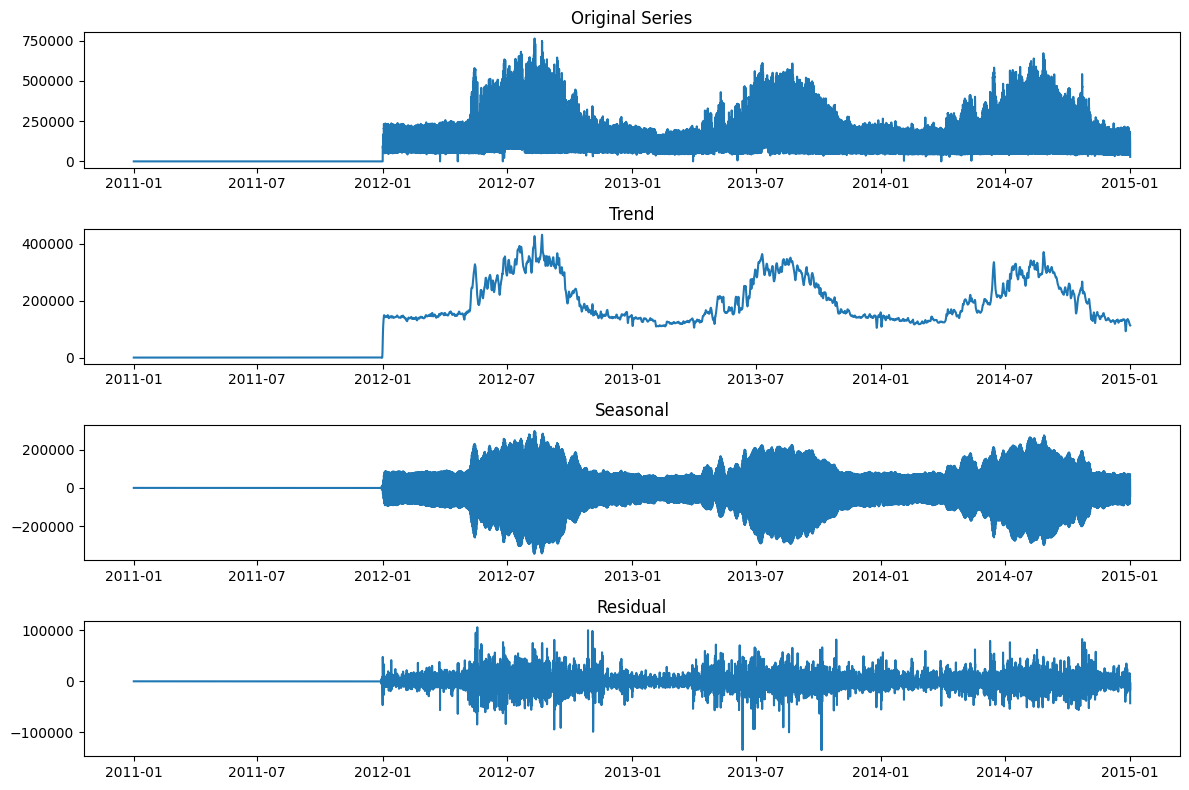

In [88]:
from statsmodels.tsa.seasonal import STL
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

meter_name = meters[0]
series = df_hourly[meter_name].copy()

print("Selected meter:", meter_name)

stl = STL(series, period=24)
res = stl.fit()

trend = res.trend
seasonal = res.seasonal
residual = res.resid

plt.figure(figsize=(12, 8))

plt.subplot(4,1,1)
plt.plot(series)
plt.title("Original Series")

plt.subplot(4,1,2)
plt.plot(trend)
plt.title("Trend")

plt.subplot(4,1,3)
plt.plot(seasonal)
plt.title("Seasonal")

plt.subplot(4,1,4)
plt.plot(residual)
plt.title("Residual")

plt.tight_layout()
plt.show()

### Compare Decomposition with Anomaly Scores

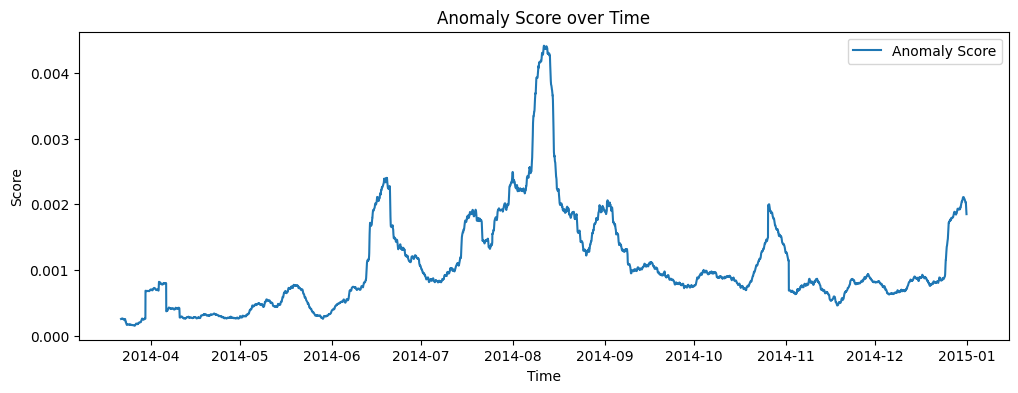

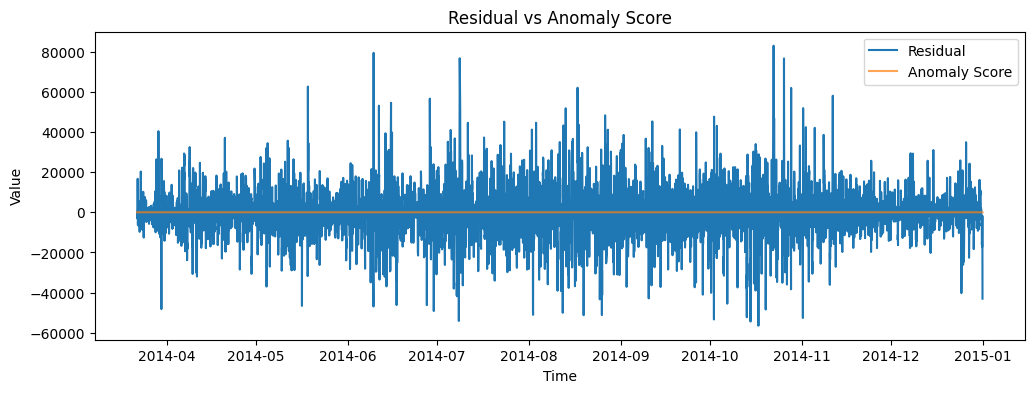

In [89]:
best_bottleneck = int(results_df.sort_values("pr_auc", ascending=False).iloc[0]["bottleneck"])
best_model = trained_models_by_bottleneck[best_bottleneck]
best_model.eval()

val_err_best = window_mse_torch(best_model, X_val, device)
val_scores_series = pd.Series(val_err_best, index=val_window_end_times) ### 

plt.figure(figsize=(12,4))
plt.plot(val_scores_series, label="Anomaly Score")
plt.title("Anomaly Score over Time")
plt.xlabel("Time")
plt.ylabel("Score")
plt.legend()
plt.show()

# Align residual with validation time
residual_aligned = residual.reindex(val_window_end_times)

plt.figure(figsize=(12,4))
plt.plot(residual_aligned, label="Residual")
plt.plot(val_scores_series, label="Anomaly Score", alpha=0.7)
plt.title("Residual vs Anomaly Score")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()

### Prepare Component-wise Datasets


In [90]:
def build_component_df(df_hourly_subset, component_type="full", period=24):
    """
    Returns a dataframe of the requested component:
    full / seasonal / residual
    """
    out = pd.DataFrame(index=df_hourly_subset.index)

    for col in df_hourly_subset.columns:
        s = df_hourly_subset[col]
        if component_type == "full":
            out[col] = s
        else:
            stl_res = STL(s, period=period).fit()
            if component_type == "seasonal":
                out[col] = stl_res.seasonal
            elif component_type == "residual":
                out[col] = stl_res.resid
            else:
                raise ValueError("component_type must be 'full', 'seasonal', or 'residual'")

    return out


def prepare_component_windows(df_component, train_end_idx, val_start_idx, top_k_meters, seq_len=168):
    """
    Build train/val windows for one component dataframe.
    Uses same split and selected meters as main project.
    """
    from sklearn.preprocessing import StandardScaler

    df_comp = df_component.copy()
    df_comp = df_comp[top_k_meters]

    train_df = df_comp.iloc[:train_end_idx].copy()
    val_df   = df_comp.iloc[val_start_idx:].copy()

    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train_df)
    val_scaled = scaler.transform(val_df)

    def make_windows(arr, seq_len=168):
        X = []
        for i in range(len(arr) - seq_len + 1):
            X.append(arr[i:i+seq_len])
        return np.array(X, dtype=np.float32)

    X_train_comp = make_windows(train_scaled, seq_len)
    X_val_comp = make_windows(val_scaled, seq_len)

    return X_train_comp, X_val_comp, scaler


def inject_synthetic_anomalies_3d(X, frac=0.05, seed=42):
    """
    3D anomaly injection for windows: (N, T, C)
    """
    rng = np.random.default_rng(seed)
    Xc = X.copy()
    n = len(Xc)
    k = max(1, int(frac * n))
    idx = rng.choice(n, size=k, replace=False)
    y = np.zeros(n, dtype=int)
    y[idx] = 1

    T = Xc.shape[1]
    C = Xc.shape[2]

    for i in idx:
        c0 = rng.integers(0, C)
        t0 = rng.integers(0, max(1, T - 6))
        mode = rng.choice(["spike", "drop", "shift"])

        if mode == "spike":
            Xc[i, t0:t0+6, c0] *= rng.uniform(3.0, 8.0)
        elif mode == "drop":
            Xc[i, t0:t0+6, c0] *= rng.uniform(0.0, 0.2)
        else:
            Xc[i, t0:t0+6, c0] += rng.uniform(1.5, 3.0)

    return Xc, y


def eval_component_model(model, X_val_comp, device):
    """
    Evaluate PR-AUC for one trained component model.
    """
    X_val_corrupt, y_true = inject_synthetic_anomalies_3d(X_val_comp, frac=0.05, seed=42)
    val_err_corrupt = window_mse_torch(model, X_val_corrupt, device)
    pr_auc = pr_auc_from_scores(y_true, val_err_corrupt)

    val_err_clean = window_mse_torch(model, X_val_comp, device)

    return pr_auc, val_err_clean, val_err_corrupt, y_true

### Prepare component datasets: full / seasonal / residual

In [91]:
# Reuse same selected meters and same split logic as project
top_k_meters = list(meters)
seq_len = 168

# If you used 80/20 split earlier on df_hourly:
n_total = len(df_hourly)
train_end_idx = int(n_total * 0.8)
val_start_idx = train_end_idx

df_full_comp = build_component_df(df_hourly[top_k_meters], component_type="full", period=24)
df_seasonal_comp = build_component_df(df_hourly[top_k_meters], component_type="seasonal", period=24)
df_residual_comp = build_component_df(df_hourly[top_k_meters], component_type="residual", period=24)

X_train_full, X_val_full, scaler_full = prepare_component_windows(
    df_full_comp, train_end_idx, val_start_idx, top_k_meters, seq_len=seq_len
)
X_train_seasonal, X_val_seasonal, scaler_seasonal = prepare_component_windows(
    df_seasonal_comp, train_end_idx, val_start_idx, top_k_meters, seq_len=seq_len
)
X_train_residual, X_val_residual, scaler_residual = prepare_component_windows(
    df_residual_comp, train_end_idx, val_start_idx, top_k_meters, seq_len=seq_len
)

print("Full windows:", X_train_full.shape, X_val_full.shape)
print("Seasonal windows:", X_train_seasonal.shape, X_val_seasonal.shape)
print("Residual windows:", X_train_residual.shape, X_val_residual.shape)

Full windows: (27885, 168, 30) (6846, 168, 30)
Seasonal windows: (27885, 168, 30) (6846, 168, 30)
Residual windows: (27885, 168, 30) (6846, 168, 30)


### Build dataloaders

In [92]:
from torch.utils.data import TensorDataset, DataLoader

batch_size = 128

def make_loader(X, batch_size=128, shuffle=True):
    Xt = torch.tensor(X, dtype=torch.float32)
    ds = TensorDataset(Xt, Xt)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader_full = make_loader(X_train_full, batch_size=batch_size, shuffle=True)
val_loader_full   = make_loader(X_val_full, batch_size=batch_size, shuffle=False)

train_loader_seasonal = make_loader(X_train_seasonal, batch_size=batch_size, shuffle=True)
val_loader_seasonal   = make_loader(X_val_seasonal, batch_size=batch_size, shuffle=False)

train_loader_residual = make_loader(X_train_residual, batch_size=batch_size, shuffle=True)
val_loader_residual   = make_loader(X_val_residual, batch_size=batch_size, shuffle=False)

### Train Full / Seasonal / Residual Models

In [93]:
component_models = {}
component_results = []

component_configs = {
    "full": (train_loader_full, val_loader_full, X_val_full),
    "seasonal": (train_loader_seasonal, val_loader_seasonal, X_val_seasonal),
    "residual": (train_loader_residual, val_loader_residual, X_val_residual)
}

best_bottleneck = int(results_df.sort_values("pr_auc", ascending=False).iloc[0]["bottleneck"])

for comp_name, (tr_loader, va_loader, X_val_comp) in component_configs.items():
    print(f"\n===== Training component model: {comp_name} =====")

    comp_model = TransformerAE(
        seq_len=seq_len,
        in_dim=len(top_k_meters),
        d_model=64,
        nhead=4,
        num_layers=2,
        bottleneck=best_bottleneck,
        dropout=0.1
    ).to(device)

    train_ae(comp_model, tr_loader, va_loader, device, epochs=10, lr=1e-3)

    pr_auc, val_err_clean_comp, val_err_corrupt_comp, y_true_comp = eval_component_model(
        comp_model, X_val_comp, device
    )

    component_models[comp_name] = comp_model
    component_results.append({
        "component": comp_name,
        "pr_auc": pr_auc,
        "recon_error_clean": float(val_err_clean_comp.mean())
    })

    print(f"{comp_name} PR-AUC: {pr_auc:.4f} | Mean clean recon error: {val_err_clean_comp.mean():.6f}")


===== Training component model: full =====
Epoch 01 | train MSE: 0.138836 | val MSE: 0.070422
Epoch 02 | train MSE: 0.035292 | val MSE: 0.036524
Epoch 03 | train MSE: 0.018575 | val MSE: 0.024476
Epoch 04 | train MSE: 0.011076 | val MSE: 0.018045
Epoch 05 | train MSE: 0.007425 | val MSE: 0.012577
Epoch 06 | train MSE: 0.005178 | val MSE: 0.009656
Epoch 07 | train MSE: 0.003972 | val MSE: 0.008135
Epoch 08 | train MSE: 0.002984 | val MSE: 0.005502
Epoch 09 | train MSE: 0.002364 | val MSE: 0.003894
Epoch 10 | train MSE: 0.001800 | val MSE: 0.002978
full PR-AUC: 0.2777 | Mean clean recon error: 0.002978

===== Training component model: seasonal =====
Epoch 01 | train MSE: 0.132719 | val MSE: 0.038276
Epoch 02 | train MSE: 0.024200 | val MSE: 0.023687
Epoch 03 | train MSE: 0.014032 | val MSE: 0.016972
Epoch 04 | train MSE: 0.009237 | val MSE: 0.012118
Epoch 05 | train MSE: 0.006448 | val MSE: 0.008720
Epoch 06 | train MSE: 0.004717 | val MSE: 0.006843
Epoch 07 | train MSE: 0.003528 | val 

### Compare Component Performance

  component    pr_auc  recon_error_clean
0  seasonal  0.308594           0.002822
1      full  0.277724           0.002978
2  residual  0.055000           0.011147


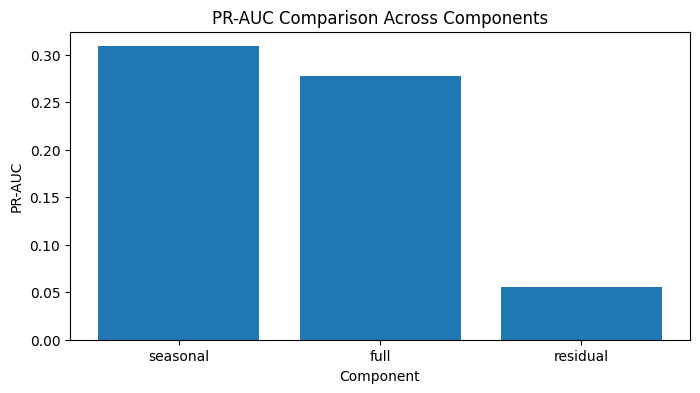

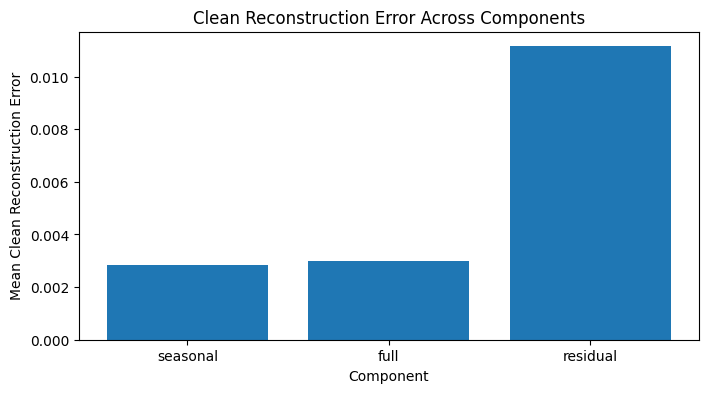

In [94]:
component_results_df = pd.DataFrame(component_results).sort_values("pr_auc", ascending=False).reset_index(drop=True)
print(component_results_df)

plt.figure(figsize=(8,4))
plt.bar(component_results_df["component"], component_results_df["pr_auc"])
plt.title("PR-AUC Comparison Across Components")
plt.xlabel("Component")
plt.ylabel("PR-AUC")
plt.show()

plt.figure(figsize=(8,4))
plt.bar(component_results_df["component"], component_results_df["recon_error_clean"])
plt.title("Clean Reconstruction Error Across Components")
plt.xlabel("Component")
plt.ylabel("Mean Clean Reconstruction Error")
plt.show()

### Identify Anomaly Type

In [95]:
if "idx" in globals():
    selected_idx = idx
else:
    selected_idx = int(np.argmax(val_err_best))

selected_time = val_window_end_times[selected_idx]
print("Selected anomalous validation time:", selected_time)

trend_val = trend.reindex([selected_time]).iloc[0] if selected_time in trend.index else np.nan
seasonal_val = seasonal.reindex([selected_time]).iloc[0] if selected_time in seasonal.index else np.nan
residual_val = residual.reindex([selected_time]).iloc[0] if selected_time in residual.index else np.nan

trend_std = np.nanstd(trend.values)
seasonal_std = np.nanstd(seasonal.values)
residual_std = np.nanstd(residual.values)

trend_score = abs(trend_val) / (trend_std + 1e-8)
seasonal_score = abs(seasonal_val) / (seasonal_std + 1e-8)
residual_score = abs(residual_val) / (residual_std + 1e-8)

type_scores = {
    "trend_break": trend_score,
    "seasonal_violation": seasonal_score,
    "noise_spike": residual_score
}

predicted_type = max(type_scores, key=type_scores.get)

print("\nAnomaly Type Scores")
print(type_scores)
print("Predicted anomaly type:", predicted_type)

Selected anomalous validation time: 2014-08-11 11:00:00

Anomaly Type Scores
{'trend_break': np.float64(3.0021193467715377), 'seasonal_violation': np.float64(1.5385830559842009), 'noise_spike': np.float64(1.2187740007118992)}
Predicted anomaly type: trend_break


### Meter-level Anomaly Type Analysis

In [96]:
meter_type_rows = []

for m in top_k_meters[:10]:   # first 10 meters for lighter analysis
    s = df_hourly[m]
    r = STL(s, period=24).fit()

    trend_m = r.trend
    seasonal_m = r.seasonal
    residual_m = r.resid

    trend_std_m = np.nanstd(trend_m.values)
    seasonal_std_m = np.nanstd(seasonal_m.values)
    residual_std_m = np.nanstd(residual_m.values)

    t_val = trend_m.reindex([selected_time]).iloc[0] if selected_time in trend_m.index else np.nan
    s_val = seasonal_m.reindex([selected_time]).iloc[0] if selected_time in seasonal_m.index else np.nan
    r_val = residual_m.reindex([selected_time]).iloc[0] if selected_time in residual_m.index else np.nan

    meter_scores = {
        "trend_break": abs(t_val) / (trend_std_m + 1e-8),
        "seasonal_violation": abs(s_val) / (seasonal_std_m + 1e-8),
        "noise_spike": abs(r_val) / (residual_std_m + 1e-8)
    }

    meter_pred = max(meter_scores, key=meter_scores.get)

    meter_type_rows.append({
        "meter": m,
        "trend_break_score": meter_scores["trend_break"],
        "seasonal_violation_score": meter_scores["seasonal_violation"],
        "noise_spike_score": meter_scores["noise_spike"],
        "predicted_type": meter_pred
    })

meter_type_df = pd.DataFrame(meter_type_rows)
print(meter_type_df)
print("\nMeter-level note:")
print("In this selected anomaly window, the first 10 analyzed meters are all classified as trend_break, indicating a consistent anomaly pattern across these meters.")

    meter  trend_break_score  seasonal_violation_score  noise_spike_score  \
0  MT_362           3.002119                  1.538583           1.218774   
1  MT_196           7.165951                  0.846355           0.879282   
2  MT_279           9.184358                  0.742744           0.459261   
3  MT_208           7.490884                  1.106303           0.383701   
4  MT_370           2.208796                  2.176111           1.892143   
5  MT_228           8.647842                  0.921007           0.237090   
6  MT_220           7.449736                  0.864756           0.477163   
7  MT_194           4.962424                  0.910415           0.198770   
8  MT_364           2.592260                  1.254758           0.538978   
9  MT_241          10.658699                  1.266772           0.832520   

  predicted_type  
0    trend_break  
1    trend_break  
2    trend_break  
3    trend_break  
4    trend_break  
5    trend_break  
6    trend_break  


### Summary

In [97]:
best_component_row = component_results_df.sort_values("pr_auc", ascending=False).iloc[0]

print("\nStage 10 Final Summary")
print("-" * 40)
print(f"Best component by PR-AUC: {best_component_row['component']}")
print(f"Best component PR-AUC: {best_component_row['pr_auc']:.4f}")
print(f"Selected anomaly time: {selected_time}")
print(f"Predicted anomaly type at selected time: {predicted_type}")
print("Interpretation: in this experiment, the seasonal component achieved the highest PR-AUC, suggesting that anomalies are more strongly associated with deviations from repeating usage patterns than with residual-only noise.")


Stage 10 Final Summary
----------------------------------------
Best component by PR-AUC: seasonal
Best component PR-AUC: 0.3086
Selected anomaly time: 2014-08-11 11:00:00
Predicted anomaly type at selected time: trend_break
Interpretation: in this experiment, the seasonal component achieved the highest PR-AUC, suggesting that anomalies are more strongly associated with deviations from repeating usage patterns than with residual-only noise.


### Save Artifacts for Dashboard

In [98]:
component_results_df.to_csv("artifacts/component_results.csv", index=False)
meter_type_df.to_csv("artifacts/meter_type_df.csv", index=False)

anomaly_type_summary = pd.DataFrame([{
    "selected_time": selected_time,
    "predicted_type": predicted_type,
    "trend_score": trend_score,
    "seasonal_score": seasonal_score,
    "residual_score": residual_score
}])
anomaly_type_summary.to_csv("artifacts/anomaly_type_summary.csv", index=False)

# Task 1: Model Export & Benchmarking (Extended)

### Select Best Model

In [99]:
import os
import time
import torch
import numpy as np
import pandas as pd

best_bottleneck = int(results_df.sort_values("pr_auc", ascending=False).iloc[0]["bottleneck"])
best_model = trained_models_by_bottleneck[best_bottleneck]
best_model.eval()

print("Using best bottleneck:", best_bottleneck)

Using best bottleneck: 32


### Export to TorchScript

In [100]:
example_input = torch.tensor(X_val[:1], dtype=torch.float32).to(device)

scripted_model = torch.jit.trace(best_model, example_input)
scripted_model.save("transformer_ae_scripted.pt")

print("Model exported to TorchScript: transformer_ae_scripted.pt")

Model exported to TorchScript: transformer_ae_scripted.pt


### Load TorchScript model

In [101]:
loaded_model = torch.jit.load("transformer_ae_scripted.pt").to(device)
loaded_model.eval()

print("TorchScript model loaded")

TorchScript model loaded


### Latency Benchmark

In [102]:
def benchmark_latency(model, xb, warmup=3, runs=10):
    model.eval()

    # warmup
    with torch.no_grad():
        for _ in range(warmup):
            _ = model(xb)

    times = []
    with torch.no_grad():
        for _ in range(runs):
            start = time.time()
            _ = model(xb)
            end = time.time()
            times.append(end - start)

    return np.mean(times), np.std(times)

xb_64 = torch.tensor(X_val[:64], dtype=torch.float32).to(device)

lat_mean_64, lat_std_64 = benchmark_latency(loaded_model, xb_64, warmup=3, runs=10)

print(f"Latency for batch of 64: {lat_mean_64:.6f} sec ± {lat_std_64:.6f}")
print(f"Latency per sample: {lat_mean_64/64:.6f} sec") 

Latency for batch of 64: 0.001571 sec ± 0.000901
Latency per sample: 0.000025 sec


### Model Size and Parameter Count

In [103]:
param_count = sum(p.numel() for p in best_model.parameters()) 
model_size_mb = param_count * 4 / (1024**2)

torchscript_size_mb = os.path.getsize("transformer_ae_scripted.pt") / (1024**2)

print("Total parameters:", param_count)
print(f"Approx parameter size (float32): {model_size_mb:.2f} MB")
print(f"TorchScript file size: {torchscript_size_mb:.2f} MB")

Total parameters: 1132734
Approx parameter size (float32): 4.32 MB
TorchScript file size: 4.47 MB


### Throughput Benchmark

In [104]:
xb_512 = torch.tensor(X_val[:512], dtype=torch.float32).to(device)

throughput_time_mean, throughput_time_std = benchmark_latency(loaded_model, xb_512, warmup=3, runs=10)
throughput = 512 / throughput_time_mean

print(f"Throughput: {throughput:.2f} windows/sec")
print(f"Batch-512 latency: {throughput_time_mean:.6f} sec ± {throughput_time_std:.6f}")

Throughput: 4966.89 windows/sec
Batch-512 latency: 0.103083 sec ± 0.062142


### CPU vs MPS Comparison

In [105]:
# CPU model
cpu_loaded_model = torch.jit.load("transformer_ae_scripted.pt").to("cpu")
cpu_loaded_model.eval()

xb_cpu = torch.tensor(X_val[:64], dtype=torch.float32).to("cpu")
cpu_mean, cpu_std = benchmark_latency(cpu_loaded_model, xb_cpu, warmup=2, runs=5)


# MPS model
mps_loaded_model = torch.jit.load("transformer_ae_scripted.pt").to(device)
mps_loaded_model.eval()

xb_mps = torch.tensor(X_val[:64], dtype=torch.float32).to(device)
mps_mean, mps_std = benchmark_latency(mps_loaded_model, xb_mps, warmup=2, runs=5)

speedup = cpu_mean / mps_mean if mps_mean > 0 else np.nan

print(f"CPU time (batch 64): {cpu_mean:.6f}s ± {cpu_std:.6f}")
print(f"MPS time (batch 64): {mps_mean:.6f}s ± {mps_std:.6f}")
print(f"MPS speedup vs CPU: {speedup:.2f}x") 

CPU time (batch 64): 0.059352s ± 0.001875
MPS time (batch 64): 0.001356s ± 0.000380
MPS speedup vs CPU: 43.78x


### Export to ONNX


In [106]:
onnx_path = "transformer_ae.onnx"

cpu_export_model = best_model.to("cpu").eval()
example_input_cpu = torch.tensor(X_val[:1], dtype=torch.float32).to("cpu")

torch.onnx.export(
    cpu_export_model,
    example_input_cpu,
    onnx_path,
    export_params=True,
    opset_version=17,
    do_constant_folding=True,
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={
        "input": {0: "batch_size"},
        "output": {0: "batch_size"}
    }
)

onnx_size_mb = os.path.getsize(onnx_path) / (1024**2)
print(f"Exported ONNX model: {onnx_path}")
print(f"ONNX file size: {onnx_size_mb:.2f} MB")

# move model back to original device for later use
best_model = best_model.to(device).eval()

/var/folders/dw/616cv9cd1fn1gjnkvzk36vvw0000gn/T/ipykernel_38425/1881749052.py:6: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(


Exported ONNX model: transformer_ae.onnx
ONNX file size: 4.46 MB


### Convert to CoreML Float16


In [107]:
import coremltools as ct
import torch

# load TorchScript model
scripted_model = torch.jit.load("transformer_ae_scripted.pt")
scripted_model.eval()

# example input shape
example_input = torch.rand(1, 168, 30)

# convert TorchScript -> CoreML with float16
mlmodel = ct.convert(
    scripted_model,
    inputs=[ct.TensorType(name="input", shape=example_input.shape)],
    compute_precision=ct.precision.FLOAT16,
    compute_units=ct.ComputeUnit.ALL
)

mlmodel.save("transformer_ae_fp16.mlpackage")
print("Converted to CoreML float16")

scikit-learn version 1.6.1 is not supported. Minimum required version: 0.17. Maximum required version: 1.5.1. Disabling scikit-learn conversion API.
Torch version 2.8.0 has not been tested with coremltools. You may run into unexpected errors. Torch 2.7.0 is the most recent version that has been tested.
When both 'convert_to' and 'minimum_deployment_target' not specified, 'convert_to' is set to "mlprogram" and 'minimum_deployment_target' is set to ct.target.iOS15 (which is same as ct.target.macOS12). Note: the model will not run on systems older than iOS15/macOS12/watchOS8/tvOS15. In order to make your model run on older system, please set the 'minimum_deployment_target' to iOS14/iOS13. Details please see the link: https://apple.github.io/coremltools/docs-guides/source/target-conversion-formats.html
Support for converting Torch Script Models is experimental. If possible you should use a traced model for conversion.
Running MIL default pipeline:   0%|          | 0/95 [00:00<?, ? passes/s

Converted to CoreML float16


### Deployment Note


In [108]:
print("\nCoreML conversion note")
print("-" * 40)
print("TorchScript export: completed")
print("ONNX export: completed")
print("CoreML float16 conversion: completed")
print("Deployment format saved for Apple ecosystem inference.")
print("KV-cached streaming inference: not implemented in this notebook; proposed as future optimization for real-time deployment.") 


CoreML conversion note
----------------------------------------
TorchScript export: completed
ONNX export: completed
CoreML float16 conversion: completed
Deployment format saved for Apple ecosystem inference.
KV-cached streaming inference: not implemented in this notebook; proposed as future optimization for real-time deployment.


### Scaling Estimate for 100 and 500 Meters


In [109]:
latency_per_window = lat_mean_64 / 64
windows_per_sec = 1.0 / latency_per_window if latency_per_window > 0 else np.nan

# If one household meter corresponds to one active window inference stream:
estimated_time_100 = 100 * latency_per_window
estimated_time_500 = 500 * latency_per_window

real_time_feasible_100 = estimated_time_100 < 1.0
real_time_feasible_500 = estimated_time_500 < 1.0

print("\nScaling estimate")
print("-" * 40)
print(f"Estimated windows/sec: {windows_per_sec:.2f}")
print(f"Estimated time for 100 concurrent meters: {estimated_time_100:.4f} sec")
print(f"Estimated time for 500 concurrent meters: {estimated_time_500:.4f} sec")
print(f"100-meter real-time feasible (<1s): {real_time_feasible_100}")
print(f"500-meter real-time feasible (<1s): {real_time_feasible_500}")


Scaling estimate
----------------------------------------
Estimated windows/sec: 40728.19
Estimated time for 100 concurrent meters: 0.0025 sec
Estimated time for 500 concurrent meters: 0.0123 sec
100-meter real-time feasible (<1s): True
500-meter real-time feasible (<1s): True


### Approximate Memory Footprint


In [110]:
input_window_mb = np.prod(X_val[:1].shape) * 4 / (1024**2)

memory_100_inputs_mb = input_window_mb * 100
memory_500_inputs_mb = input_window_mb * 500

print("\nApprox input memory footprint")
print("-" * 40)
print(f"One input window memory: {input_window_mb:.4f} MB")
print(f"100 concurrent input windows: {memory_100_inputs_mb:.2f} MB")
print(f"500 concurrent input windows: {memory_500_inputs_mb:.2f} MB")
print(f"Model parameter memory: {model_size_mb:.2f} MB")
print(f"Approx total for 100 meters: {model_size_mb + memory_100_inputs_mb:.2f} MB")
print(f"Approx total for 500 meters: {model_size_mb + memory_500_inputs_mb:.2f} MB")


Approx input memory footprint
----------------------------------------
One input window memory: 0.0192 MB
100 concurrent input windows: 1.92 MB
500 concurrent input windows: 9.61 MB
Model parameter memory: 4.32 MB
Approx total for 100 meters: 6.24 MB
Approx total for 500 meters: 13.93 MB


### Summary


In [113]:
Task1_summary = {
    "best_bottleneck": best_bottleneck,
    "torchscript_file_mb": torchscript_size_mb,
    "onnx_file_mb": onnx_size_mb,
    "param_size_mb": model_size_mb,
    "latency_batch_64_sec": lat_mean_64,
    "latency_per_sample_sec": lat_mean_64 / 64,
    "throughput_windows_per_sec": throughput,
    "cpu_batch64_sec": cpu_mean,
    "mps_batch64_sec": mps_mean,
    "mps_speedup_vs_cpu": speedup,
    "estimated_time_100_sec": estimated_time_100,
    "estimated_time_500_sec": estimated_time_500,
    "real_time_100_feasible": real_time_feasible_100,
    "real_time_500_feasible": real_time_feasible_500,
    "coreml_conversion": True
}

stage11_df = pd.DataFrame([Task1_summary])
print(stage11_df.T)

stage11_df.to_csv("Task_1_benchmark_summary.csv", index=False)
print("Saved: Task_1_benchmark_summary.csv")

                                      0
best_bottleneck                      32
torchscript_file_mb            4.470937
onnx_file_mb                   4.460883
param_size_mb                  4.321037
latency_batch_64_sec           0.001571
latency_per_sample_sec         0.000025
throughput_windows_per_sec  4966.892485
cpu_batch64_sec                0.059352
mps_batch64_sec                0.001356
mps_speedup_vs_cpu            43.782476
estimated_time_100_sec         0.002455
estimated_time_500_sec         0.012277
real_time_100_feasible             True
real_time_500_feasible             True
coreml_conversion                  True
Saved: Task_1_benchmark_summary.csv


# Task 5: Adversarial Robustness (Extended)

### Select Best Baseline Model


In [114]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import copy

best_bottleneck = int(results_df.sort_values("pr_auc", ascending=False).iloc[0]["bottleneck"])
base_model = trained_models_by_bottleneck[best_bottleneck]
base_model.eval()

print("Using best bottleneck:", best_bottleneck) 

Using best bottleneck: 32


### Baseline Performance on Clean and Corrupted Validation Data

In [115]:
X_val_corrupt, y_true = inject_synthetic_anomalies(X_val, frac=0.05, seed=42)

val_err_clean_base = window_mse_torch(base_model, X_val, device)
val_err_corrupt_base = window_mse_torch(base_model, X_val_corrupt, device)

pr_clean = pr_auc_from_scores(y_true, val_err_corrupt_base)

print("Baseline PR-AUC:", pr_clean)
print("Mean clean reconstruction error:", float(val_err_clean_base.mean()))

Baseline PR-AUC: 0.3712456036697509
Mean clean reconstruction error: 0.0010679461993277073


### Utility for Measuring Missed Anomaly Rate

In [116]:
def missed_anomaly_rate(clean_scores, test_scores, y_true, percentile=95):
    threshold = np.percentile(clean_scores, percentile)
    pred = (test_scores >= threshold).astype(int)

    anomaly_mask = (y_true == 1)
    if anomaly_mask.sum() == 0:
        return 0.0, threshold

    missed = ((pred == 0) & anomaly_mask).sum()
    missed_rate = missed / anomaly_mask.sum()

    return missed_rate, threshold

### Gaussian Noise Robustness


In [117]:
noise_levels = [0.01, 0.03, 0.05, 0.1]
robust_results = []

for nl in noise_levels:
    X_noisy = X_val + np.random.normal(0, nl, X_val.shape)

    X_noisy_corrupt, y_true_noisy = inject_synthetic_anomalies(X_noisy, frac=0.05, seed=42)
    val_err_noisy = window_mse_torch(base_model, X_noisy_corrupt, device)

    pr = pr_auc_from_scores(y_true_noisy, val_err_noisy)
    missed_rate, threshold = missed_anomaly_rate(val_err_clean_base, val_err_noisy, y_true_noisy, percentile=95)

    robust_results.append({
        "attack_type": "gaussian_noise",
        "strength": nl,
        "pr_auc": pr,
        "missed_anomaly_rate": missed_rate,
        "threshold": threshold
    })

    print(f"Noise {nl}: PR-AUC = {pr:.4f} | Missed anomaly rate = {missed_rate:.4f}")

Noise 0.01: PR-AUC = 0.3723 | Missed anomaly rate = 0.5819
Noise 0.03: PR-AUC = 0.3717 | Missed anomaly rate = 0.5760
Noise 0.05: PR-AUC = 0.3718 | Missed anomaly rate = 0.5643
Noise 0.1: PR-AUC = 0.3755 | Missed anomaly rate = 0.4825


#### Realistic Threats: Sensor Drift, Calibration Error, Partial Outage

In [118]:
def apply_sensor_drift(X, drift_strength=0.05):
    Xd = X.copy()
    n, T, C = Xd.shape
    drift = np.linspace(0, drift_strength, T).reshape(1, T, 1)
    Xd = Xd + drift
    return Xd

def apply_calibration_error(X, scale_strength=0.1):
    Xc = X.copy()
    n, T, C = Xc.shape
    scales = np.random.uniform(1 - scale_strength, 1 + scale_strength, size=(1, 1, C))
    Xc = Xc * scales
    return Xc

def apply_partial_outage(X, frac_channels=0.1):
    Xp = X.copy()
    n, T, C = Xp.shape
    k = max(1, int(frac_channels * C))
    ch_idx = np.random.choice(C, size=k, replace=False)
    Xp[:, :, ch_idx] = 0.0
    return Xp, ch_idx

threat_rows = []

# Sensor drift
for strength in [0.02, 0.05, 0.1]:
    X_attack = apply_sensor_drift(X_val, drift_strength=strength)
    X_attack_corrupt, y_attack = inject_synthetic_anomalies(X_attack, frac=0.05, seed=42)
    scores = window_mse_torch(base_model, X_attack_corrupt, device)

    pr = pr_auc_from_scores(y_attack, scores)
    missed_rate, threshold = missed_anomaly_rate(val_err_clean_base, scores, y_attack, percentile=95)

    threat_rows.append({
        "attack_type": "sensor_drift",
        "strength": strength,
        "pr_auc": pr,
        "missed_anomaly_rate": missed_rate,
        "threshold": threshold
    })

# Calibration error
for strength in [0.05, 0.1, 0.2]:
    X_attack = apply_calibration_error(X_val, scale_strength=strength)
    X_attack_corrupt, y_attack = inject_synthetic_anomalies(X_attack, frac=0.05, seed=42)
    scores = window_mse_torch(base_model, X_attack_corrupt, device)

    pr = pr_auc_from_scores(y_attack, scores)
    missed_rate, threshold = missed_anomaly_rate(val_err_clean_base, scores, y_attack, percentile=95)

    threat_rows.append({
        "attack_type": "calibration_error",
        "strength": strength,
        "pr_auc": pr,
        "missed_anomaly_rate": missed_rate,
        "threshold": threshold
    })

# Partial outage
for strength in [0.05, 0.1, 0.2]:
    X_attack, ch_idx = apply_partial_outage(X_val, frac_channels=strength)
    X_attack_corrupt, y_attack = inject_synthetic_anomalies(X_attack, frac=0.05, seed=42)
    scores = window_mse_torch(base_model, X_attack_corrupt, device)

    pr = pr_auc_from_scores(y_attack, scores)
    missed_rate, threshold = missed_anomaly_rate(val_err_clean_base, scores, y_attack, percentile=95)

    threat_rows.append({
        "attack_type": "partial_outage",
        "strength": strength,
        "pr_auc": pr,
        "missed_anomaly_rate": missed_rate,
        "threshold": threshold
    })

threat_df = pd.DataFrame(threat_rows)
print(threat_df) 

         attack_type  strength    pr_auc  missed_anomaly_rate  threshold
0       sensor_drift      0.02  0.372039             0.587719   0.002268
1       sensor_drift      0.05  0.372994             0.593567   0.002268
2       sensor_drift      0.10  0.372617             0.605263   0.002268
3  calibration_error      0.05  0.363074             0.546784   0.002268
4  calibration_error      0.10  0.389403             0.614035   0.002268
5  calibration_error      0.20  0.353243             0.429825   0.002268
6     partial_outage      0.05  0.342652             0.464912   0.002268
7     partial_outage      0.10  0.176728             0.000000   0.002268
8     partial_outage      0.20  0.122900             0.000000   0.002268


### PGD-style Adversarial Attack


In [119]:
def pgd_attack_reconstruction(model, X_np, device, epsilon=0.03, alpha=0.01, steps=5, batch_size=64):
    model.eval()
    adv_batches = []

    for i in range(0, len(X_np), batch_size):
        xb = torch.tensor(X_np[i:i+batch_size], dtype=torch.float32, device=device)
        x_orig = xb.clone().detach()
        x_adv = xb.clone().detach()

        for _ in range(steps):
            x_adv.requires_grad_(True)

            pred = model(x_adv)
            loss = torch.mean((pred - x_adv) ** 2)

            model.zero_grad()
            if x_adv.grad is not None:
                x_adv.grad.zero_()
            loss.backward()

            grad_sign = x_adv.grad.sign()
            x_adv = x_adv.detach() + alpha * grad_sign

            perturb = torch.clamp(x_adv - x_orig, min=-epsilon, max=epsilon)
            x_adv = (x_orig + perturb).detach()

        adv_batches.append(x_adv.cpu().numpy())

        del xb, x_orig, x_adv, pred, loss, perturb, grad_sign
        if device == "mps" or str(device) == "mps":
            torch.mps.empty_cache()

    return np.concatenate(adv_batches, axis=0)

pgd_results = []

for eps in [0.01, 0.03, 0.05, 0.1]:
    X_adv = pgd_attack_reconstruction(base_model, X_val, device, epsilon=eps, alpha=eps/3, steps=5)
    X_adv_corrupt, y_adv = inject_synthetic_anomalies(X_adv, frac=0.05, seed=42)

    adv_scores = window_mse_torch(base_model, X_adv_corrupt, device)
    pr_adv = pr_auc_from_scores(y_adv, adv_scores)
    missed_rate, threshold = missed_anomaly_rate(val_err_clean_base, adv_scores, y_adv, percentile=95)

    pgd_results.append({
        "attack_type": "pgd_attack",
        "strength": eps,
        "pr_auc": pr_adv,
        "missed_anomaly_rate": missed_rate,
        "threshold": threshold
    })

pgd_df = pd.DataFrame(pgd_results)
print(pgd_df) 

  attack_type  strength    pr_auc  missed_anomaly_rate  threshold
0  pgd_attack      0.01  0.359808             0.532164   0.002268
1  pgd_attack      0.03  0.337868             0.409357   0.002268
2  pgd_attack      0.05  0.317750             0.178363   0.002268
3  pgd_attack      0.10  0.264134             0.000000   0.002268


### Aggregate Robustness Results and Visualize

          attack_type  strength    pr_auc  missed_anomaly_rate  threshold
0      gaussian_noise      0.01  0.372308             0.581871   0.002268
1      gaussian_noise      0.03  0.371670             0.576023   0.002268
2      gaussian_noise      0.05  0.371842             0.564327   0.002268
3      gaussian_noise      0.10  0.375545             0.482456   0.002268
4        sensor_drift      0.02  0.372039             0.587719   0.002268
5        sensor_drift      0.05  0.372994             0.593567   0.002268
6        sensor_drift      0.10  0.372617             0.605263   0.002268
7   calibration_error      0.05  0.363074             0.546784   0.002268
8   calibration_error      0.10  0.389403             0.614035   0.002268
9   calibration_error      0.20  0.353243             0.429825   0.002268
10     partial_outage      0.05  0.342652             0.464912   0.002268
11     partial_outage      0.10  0.176728             0.000000   0.002268
12     partial_outage      0.20  0.122

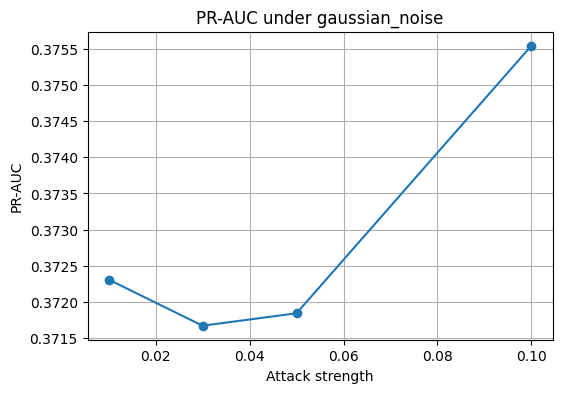

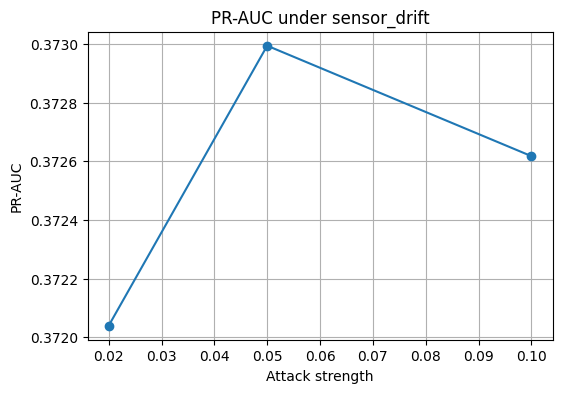

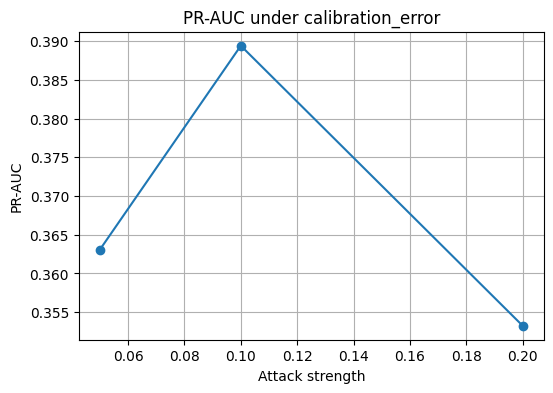

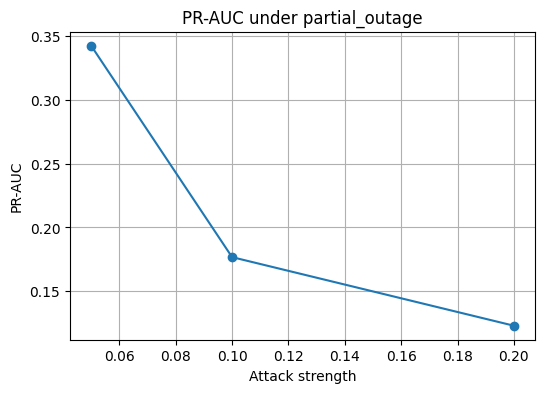

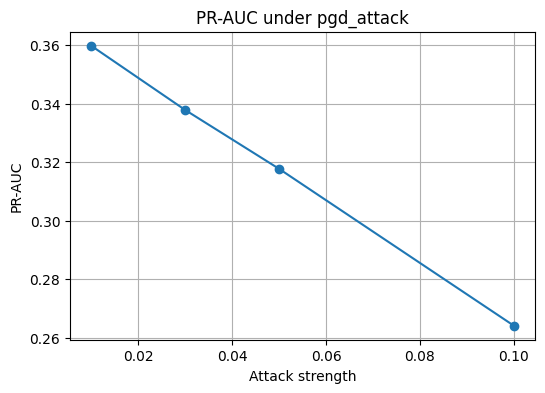

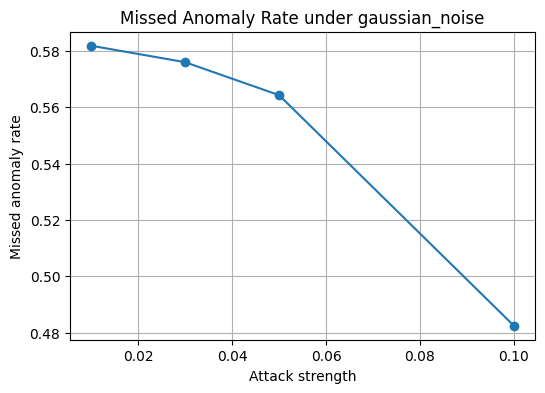

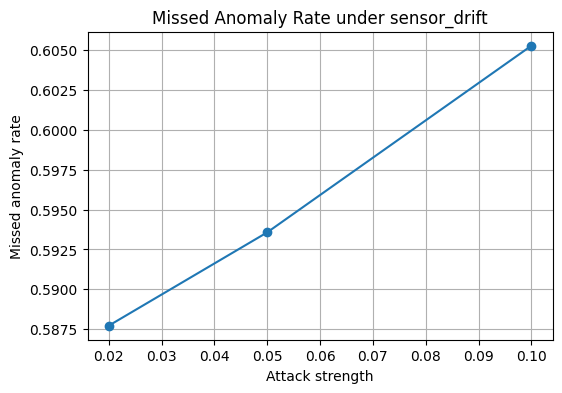

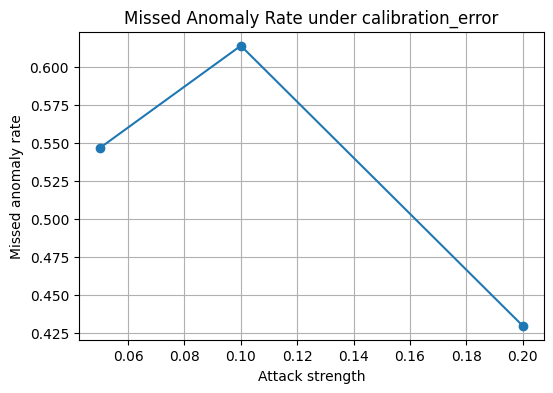

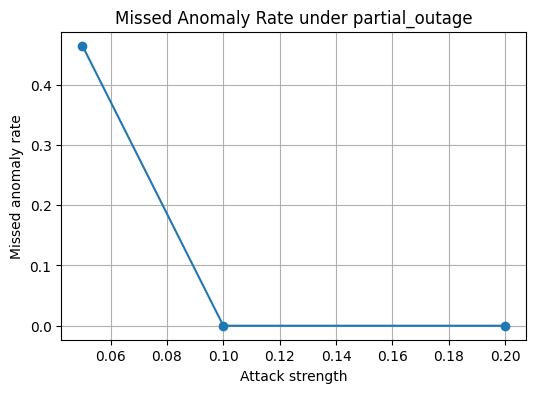

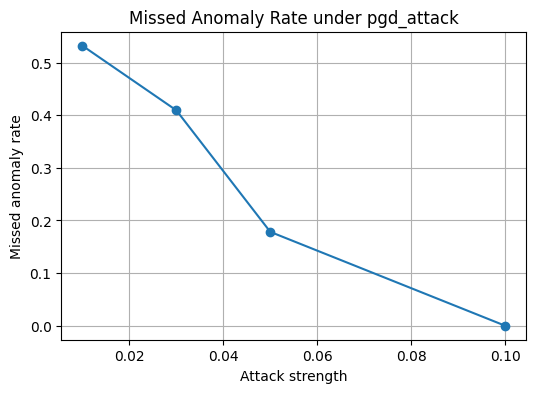

In [120]:
robust_df = pd.concat([
    pd.DataFrame(robust_results),
    threat_df,
    pgd_df
], ignore_index=True)

print(robust_df)

# PR-AUC plot by attack type
for attack_name in robust_df["attack_type"].unique():
    sub = robust_df[robust_df["attack_type"] == attack_name]

    plt.figure(figsize=(6,4))
    plt.plot(sub["strength"], sub["pr_auc"], marker='o')
    plt.title(f"PR-AUC under {attack_name}")
    plt.xlabel("Attack strength")
    plt.ylabel("PR-AUC")
    plt.grid(True)
    plt.show()

# Missed anomaly rate plot by attack type
for attack_name in robust_df["attack_type"].unique():
    sub = robust_df[robust_df["attack_type"] == attack_name]

    plt.figure(figsize=(6,4))
    plt.plot(sub["strength"], sub["missed_anomaly_rate"], marker='o')
    plt.title(f"Missed Anomaly Rate under {attack_name}")
    plt.xlabel("Attack strength")
    plt.ylabel("Missed anomaly rate")
    plt.grid(True)
    plt.show()

### Build Adversarially-Augmented Training Data

In [121]:
subset_n = min(2000, len(X_train))
X_train_subset = X_train[:subset_n].copy()

X_train_adv = pgd_attack_reconstruction(
    base_model, X_train_subset, device,
    epsilon=0.03, alpha=0.01, steps=5, batch_size=32
)

X_train_mix = np.concatenate([X_train_subset, X_train_adv], axis=0).astype(np.float32)

print("Original subset shape:", X_train_subset.shape)
print("Adversarial subset shape:", X_train_adv.shape)
print("Mixed training shape:", X_train_mix.shape)

Original subset shape: (2000, 168, 30)
Adversarial subset shape: (2000, 168, 30)
Mixed training shape: (4000, 168, 30)


### Build Dataloaders for Adversarial Training

In [122]:
from torch.utils.data import TensorDataset, DataLoader

Xt_mix = torch.tensor(X_train_mix, dtype=torch.float32)
train_mix_ds = TensorDataset(Xt_mix, Xt_mix)
train_mix_loader = DataLoader(train_mix_ds, batch_size=128, shuffle=True)

val_ds = TensorDataset(
    torch.tensor(X_val, dtype=torch.float32),
    torch.tensor(X_val, dtype=torch.float32)
)
val_loader_stage12 = DataLoader(val_ds, batch_size=128, shuffle=False)

print("Dataloaders ready")

Dataloaders ready


### Train Adversarially-Robust Model


In [123]:
robust_model = TransformerAE(
    seq_len=168,
    in_dim=K,
    d_model=64,
    nhead=4,
    num_layers=2,
    bottleneck=best_bottleneck,
    dropout=0.1
).to(device)

_ = train_ae(robust_model, train_mix_loader, val_loader_stage12, device, epochs=5, lr=1e-3)
robust_model.eval() 

Epoch 01 | train MSE: 0.336509 | val MSE: 1.625164
Epoch 02 | train MSE: 0.121283 | val MSE: 1.488521
Epoch 03 | train MSE: 0.104173 | val MSE: 1.498228
Epoch 04 | train MSE: 0.091205 | val MSE: 1.447084
Epoch 05 | train MSE: 0.061447 | val MSE: 1.436840


TransformerAE(
  (in_proj): Linear(in_features=30, out_features=64, bias=True)
  (pos): PositionalEncoding()
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (to_latent): Linear(in_features=64, out_features=32, bias=True)
  (from_latent): Linear(in_features=32, out_features=64, bias=True)
  (decoder): TransformerEncoder(
    (layers): ModuleLis

#### Compare Vanilla vs Adversarially-Trained Model

In [124]:
compare_rows = []
X_val_compare = X_val[:1000]

for eps in [0.01, 0.03, 0.05, 0.1]:
    X_adv_test = pgd_attack_reconstruction(
        base_model, X_val_compare, device,
        epsilon=eps, alpha=eps/3, steps=5, batch_size=32
    )
    X_adv_test_corrupt, y_adv_test = inject_synthetic_anomalies(X_adv_test, frac=0.05, seed=42)

    vanilla_scores = window_mse_torch(base_model, X_adv_test_corrupt, device)
    robust_scores = window_mse_torch(robust_model, X_adv_test_corrupt, device)

    vanilla_pr = pr_auc_from_scores(y_adv_test, vanilla_scores)
    robust_pr = pr_auc_from_scores(y_adv_test, robust_scores)

    vanilla_clean_scores = window_mse_torch(base_model, X_val_compare, device)
    vanilla_missed, _ = missed_anomaly_rate(vanilla_clean_scores, vanilla_scores, y_adv_test, percentile=95)

    robust_clean_scores = window_mse_torch(robust_model, X_val_compare, device)
    robust_missed, _ = missed_anomaly_rate(robust_clean_scores, robust_scores, y_adv_test, percentile=95)

    compare_rows.append({
        "epsilon": eps,
        "vanilla_pr_auc": vanilla_pr,
        "robust_pr_auc": robust_pr,
        "vanilla_missed_rate": vanilla_missed,
        "robust_missed_rate": robust_missed
    })

compare_df = pd.DataFrame(compare_rows)
print(compare_df)
print("\nComparison note:")
print("In this experiment, the adversarially-trained model did not outperform the vanilla model on PR-AUC.")
print("This suggests that the current adversarial training setup may need more tuning, such as different epsilon values, training duration, or attack strategy.")

   epsilon  vanilla_pr_auc  robust_pr_auc  vanilla_missed_rate  \
0     0.01        0.441262       0.229901                 0.56   
1     0.03        0.421048       0.227916                 0.22   
2     0.05        0.364024       0.218607                 0.00   
3     0.10        0.262554       0.227751                 0.00   

   robust_missed_rate  
0                0.76  
1                0.76  
2                0.74  
3                0.70  

Comparison note:
In this experiment, the adversarially-trained model did not outperform the vanilla model on PR-AUC.
This suggests that the current adversarial training setup may need more tuning, such as different epsilon values, training duration, or attack strategy.


### Visual Comparison Under PGD

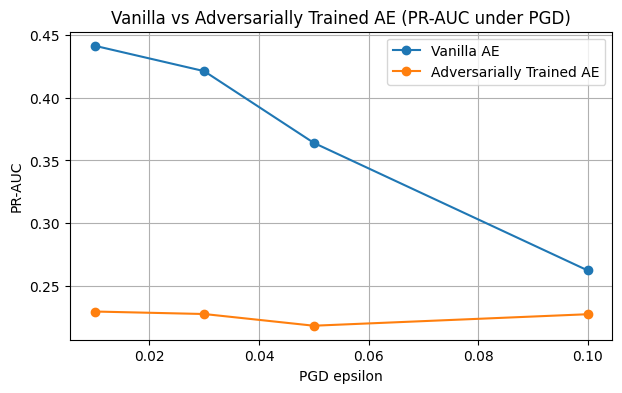

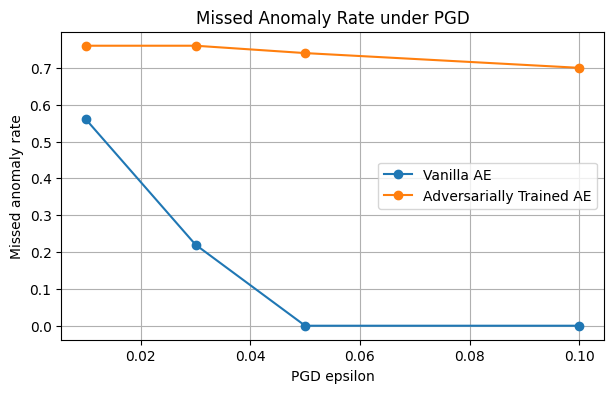

In [125]:
plt.figure(figsize=(7,4))
plt.plot(compare_df["epsilon"], compare_df["vanilla_pr_auc"], marker='o', label="Vanilla AE")
plt.plot(compare_df["epsilon"], compare_df["robust_pr_auc"], marker='o', label="Adversarially Trained AE")
plt.title("Vanilla vs Adversarially Trained AE (PR-AUC under PGD)")
plt.xlabel("PGD epsilon")
plt.ylabel("PR-AUC")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7,4))
plt.plot(compare_df["epsilon"], compare_df["vanilla_missed_rate"], marker='o', label="Vanilla AE")
plt.plot(compare_df["epsilon"], compare_df["robust_missed_rate"], marker='o', label="Adversarially Trained AE")
plt.title("Missed Anomaly Rate under PGD")
plt.xlabel("PGD epsilon")
plt.ylabel("Missed anomaly rate")
plt.legend()
plt.grid(True)
plt.show() 

### Summary


In [126]:
worst_attack_row = robust_df.sort_values("pr_auc").iloc[0]

print("\nFinal Summary")
print("-" * 40)
print(f"Baseline PR-AUC: {pr_clean:.4f}")
print(f"Worst attack type: {worst_attack_row['attack_type']}")
print(f"Worst attack strength: {worst_attack_row['strength']}")
print(f"Worst-case PR-AUC: {worst_attack_row['pr_auc']:.4f}")
print(f"Worst-case missed anomaly rate: {worst_attack_row['missed_anomaly_rate']:.4f}")
print("Interpretation: stronger perturbations reduce anomaly detection performance, and adversarial training can be used to improve robustness.")


Final Summary
----------------------------------------
Baseline PR-AUC: 0.3712
Worst attack type: partial_outage
Worst attack strength: 0.2
Worst-case PR-AUC: 0.1229
Worst-case missed anomaly rate: 0.0000
Interpretation: stronger perturbations reduce anomaly detection performance, and adversarial training can be used to improve robustness.
